In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import pandas as pd
import arviz as az
from scipy.stats import kstest
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from IPython.display import Latex, display
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pytensor.tensor as pt
import functions
from pytensor.scan.basic import scan
from scipy.special import logsumexp
from scipy.special import gammaincc  # regularized upper gamma
import xarray as xr
from scipy.special import gamma as gamma_fn
from scipy.stats import gamma as sp_gamma, weibull_min
from math import sqrt
import time
import re
import os
import sys
from math import sqrt
from scipy.stats import norm
from functions import *

# keep BLAS forks tame (helps on WSL/low RAM)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

plt.style.use("ggplot")

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
print("Python:", sys.version)
print("PyMC:", pm.__version__)

Python: 3.10.13 | packaged by conda-forge | (main, Oct 26 2023, 18:07:37) [GCC 12.3.0]
PyMC: 5.25.1


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
OUT = Path("figs"); OUT.mkdir(exist_ok=True)

In [5]:
file_path = 'bitcoin_blocks_and_transactions_sorted.csv'
pd.set_option('display.max_columns', None)
df = pd.read_csv(file_path,index_col=False)
num_rows = df.shape[0]
print(f"Number of rows using .shape[0]: {num_rows}")

df.head()

Number of rows using .shape[0]: 15000


,id,height,version,timestamp,tx_count,size,weight,merkle_root,previousblockhash,mediantime,nonce,bits,difficulty,total_trans_fees,input_count,output_count,input_value
0,00000000000000000001c827e4d9c2360756e5d76e492b...,862501,603979776,1727084204,2277,1856961,3992901,17d01c5d7b8441565de2ccf4db0e8163403b0899007f07...,00000000000000000002d5b4f115ca2458acb75a13422e...,1727081265,978191335,386075020,9.267158e+13,4271007,10932.0,1.021110e+11,1.017980e+11
1,0000000000000000000165f7b6a0c0ef25ea3cae79c865...,862502,738197504,1727084749,2341,1839000,3993360,47ed70e4da0f302114fc572bab062c99c0bbe3070fd315...,00000000000000000001c827e4d9c2360756e5d76e492b...,1727082238,827544669,386075020,9.267158e+13,4302041,10719.0,7.759630e+11,7.756510e+11
2,00000000000000000001a519c445c0a3f1319630603560...,862503,823279616,1727085461,3137,1645376,3993413,eeff8b0b686006f32aedbe7d4c0eaaa321b6fd73c8c723...,0000000000000000000165f7b6a0c0ef25ea3cae79c865...,1727082320,871041503,386075020,9.267158e+13,5259048,8704.0,1.899960e+11,1.896830e+11
3,000000000000000000020bce365f1f28bc4d51779fdb02...,862504,536911872,1727086363,3447,1716979,3993739,dc16c1f3d16552542d1a10894dbcc7fda6464ea7f3f055...,00000000000000000001a519c445c0a3f1319630603560...,1727082730,3106376116,386075020,9.267158e+13,5575404,8815.0,2.577620e+12,2.577300e+12
4,000000000000000000020a8002a7488358d0a7313a00c9...,862505,1073676288,1727087094,3360,1741490,3997772,e0450adca29bf1be837896b4ea3c8ad693079529bc80e2...,000000000000000000020bce365f1f28bc4d51779fdb02...,1727083818,610837269,386075020,9.267158e+13,5149822,8926.0,5.237330e+11,5.234210e+11


In [6]:
columns_to_drop = ['id','height', 'merkle_root','previousblockhash','mediantime']
df = df.drop(columns_to_drop, axis=1)

df.insert(0, 'formatted_timestamp', pd.to_datetime(df['timestamp'],unit='s'))

df= df.sort_values(by='formatted_timestamp', ascending=True)

arrival_interval = round(pd.to_datetime(df['timestamp'],unit='s').diff().dt.total_seconds())
df.insert(0, 'arrival_interval', arrival_interval)

df.head()

,arrival_interval,formatted_timestamp,version,timestamp,tx_count,size,weight,nonce,bits,difficulty,total_trans_fees,input_count,output_count,input_value
0,NaN,2024-09-23 09:36:44,603979776,1727084204,2277,1856961,3992901,978191335,386075020,9.267158e+13,4271007,10932.0,1.021110e+11,1.017980e+11
1,545.0,2024-09-23 09:45:49,738197504,1727084749,2341,1839000,3993360,827544669,386075020,9.267158e+13,4302041,10719.0,7.759630e+11,7.756510e+11
2,712.0,2024-09-23 09:57:41,823279616,1727085461,3137,1645376,3993413,871041503,386075020,9.267158e+13,5259048,8704.0,1.899960e+11,1.896830e+11
3,902.0,2024-09-23 10:12:43,536911872,1727086363,3447,1716979,3993739,3106376116,386075020,9.267158e+13,5575404,8815.0,2.577620e+12,2.577300e+12
4,731.0,2024-09-23 10:24:54,1073676288,1727087094,3360,1741490,3997772,610837269,386075020,9.267158e+13,5149822,8926.0,5.237330e+11,5.234210e+11


In [7]:
df.iat[0, 0] = 0
df['difficulty'] = pd.to_numeric(df['difficulty'], errors='coerce')
df.head()

,arrival_interval,formatted_timestamp,version,timestamp,tx_count,size,weight,nonce,bits,difficulty,total_trans_fees,input_count,output_count,input_value
0,0.0,2024-09-23 09:36:44,603979776,1727084204,2277,1856961,3992901,978191335,386075020,9.267158e+13,4271007,10932.0,1.021110e+11,1.017980e+11
1,545.0,2024-09-23 09:45:49,738197504,1727084749,2341,1839000,3993360,827544669,386075020,9.267158e+13,4302041,10719.0,7.759630e+11,7.756510e+11
2,712.0,2024-09-23 09:57:41,823279616,1727085461,3137,1645376,3993413,871041503,386075020,9.267158e+13,5259048,8704.0,1.899960e+11,1.896830e+11
3,902.0,2024-09-23 10:12:43,536911872,1727086363,3447,1716979,3993739,3106376116,386075020,9.267158e+13,5575404,8815.0,2.577620e+12,2.577300e+12
4,731.0,2024-09-23 10:24:54,1073676288,1727087094,3360,1741490,3997772,610837269,386075020,9.267158e+13,5149822,8926.0,5.237330e+11,5.234210e+11


In [8]:
df_head = df.head()
latex_table_string = df_head.to_latex(
    index=False,
    caption="First 5 rows of DataFrame",
    label="tab:dataframe_head"
)
display(Latex(latex_table_string))

<IPython.core.display.Latex object>

In [9]:
def zscore_safe(a):
    a = np.asarray(a, float)
    m = np.nanmean(a)
    s = np.nanstd(a)
    if not np.isfinite(s) or s == 0:
        # column is constant or degenerate -> use zeros (no signal, no NaNs)
        return np.zeros_like(a)
    return (a - m) / s

In [36]:
transformed_df = df[['arrival_interval', 'formatted_timestamp','timestamp','tx_count', 'size','weight','difficulty','total_trans_fees','input_count','output_count']].copy()
transformed_df.loc[:, 'tx_count'] = zscore_safe(transformed_df['tx_count'])
transformed_df.loc[:, 'size'] = zscore_safe(transformed_df['size'])
transformed_df.loc[:, 'weight'] = zscore_safe(transformed_df['weight'])
transformed_df.loc[:, 'difficulty'] = zscore_safe(transformed_df['difficulty'])
transformed_df.loc[:, 'total_trans_fees'] = zscore_safe(transformed_df['total_trans_fees'])
transformed_df.loc[:, 'input_count'] = zscore_safe(transformed_df['input_count'])
transformed_df.loc[:, 'output_count'] = zscore_safe(transformed_df['output_count'])
transformed_df.head()

/tmp/ipykernel_2647/157679475.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.87962238 -0.83694578 -0.3061556  ...  0.44935355  0.31532236
  0.89212325]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  transformed_df.loc[:, 'tx_count'] = zscore_safe(transformed_df['tx_count'])
/tmp/ipykernel_2647/157679475.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.92534694 0.85333421 0.07701921 ... 0.38512113 0.44475686 0.74279921]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  transformed_df.loc[:, 'size'] = zscore_safe(transformed_df['size'])
/tmp/ipykernel_2647/157679475.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.04987307 0.0519989  0.05224437 ... 0.05196648 0.05200816 0.0

,arrival_interval,formatted_timestamp,timestamp,tx_count,size,weight,difficulty,total_trans_fees,input_count,output_count
0,0.0,2024-09-23 09:36:44,1727084204,-0.879622,0.925347,0.049873,-0.959087,-0.311823,2.404903,-0.622570
1,545.0,2024-09-23 09:45:49,1727084749,-0.836946,0.853334,0.051999,-0.959087,-0.310347,2.248207,0.428797
2,712.0,2024-09-23 09:57:41,1727085461,-0.306156,0.077019,0.052244,-0.959087,-0.264843,0.765847,-0.485449
3,902.0,2024-09-23 10:12:43,1727086363,-0.099441,0.364104,0.053754,-0.959087,-0.249800,0.847505,3.239804
4,731.0,2024-09-23 10:24:54,1727087094,-0.157454,0.462378,0.072433,-0.959087,-0.270036,0.929164,0.035259


In [37]:
latex_table_string_transformed_data= transformed_df.head().to_latex(
    index=False,
    caption="First 5 rows of the transformed dataset",
    label="tab:transformed_dataset"
)
display(Latex(latex_table_string_transformed_data))

<IPython.core.display.Latex object>

In [38]:
corr_checks_columns = df[['tx_count', 'size','weight','difficulty','total_trans_fees','input_count','output_count','input_value']]
corr = corr_checks_columns.corr(numeric_only=True).round(2)
corr

,tx_count,size,weight,difficulty,total_trans_fees,input_count,output_count,input_value
tx_count,1.00,-0.12,0.13,-0.38,0.20,0.00,-0.00,-0.01
size,-0.12,1.00,0.35,-0.03,-0.11,0.16,-0.07,-0.09
weight,0.13,0.35,1.00,0.01,0.03,0.31,0.04,0.01
difficulty,-0.38,-0.03,0.01,1.00,-0.07,-0.11,0.04,0.04
total_trans_fees,0.20,-0.11,0.03,-0.07,1.00,-0.06,0.08,0.08
input_count,0.00,0.16,0.31,-0.11,-0.06,1.00,-0.04,-0.06
output_count,-0.00,-0.07,0.04,0.04,0.08,-0.04,1.00,1.00
input_value,-0.01,-0.09,0.01,0.04,0.08,-0.06,1.00,1.00


In [39]:
latex_corr_table = corr.to_latex(
    float_format="%.2f",
    index=True,
    header=True,
    caption="Correlation matrix of numeric variables.",
    label="tab:corr_matrix",
    escape=False,
    longtable=False  # change to True if the table is wide
)

print(latex_corr_table)

\begin{table}
\caption{Correlation matrix of numeric variables.}
\label{tab:corr_matrix}
\begin{tabular}{lrrrrrrrr}
\toprule
 & tx_count & size & weight & difficulty & total_trans_fees & input_count & output_count & input_value \\
\midrule
tx_count & 1.00 & -0.12 & 0.13 & -0.38 & 0.20 & 0.00 & -0.00 & -0.01 \\
size & -0.12 & 1.00 & 0.35 & -0.03 & -0.11 & 0.16 & -0.07 & -0.09 \\
weight & 0.13 & 0.35 & 1.00 & 0.01 & 0.03 & 0.31 & 0.04 & 0.01 \\
difficulty & -0.38 & -0.03 & 0.01 & 1.00 & -0.07 & -0.11 & 0.04 & 0.04 \\
total_trans_fees & 0.20 & -0.11 & 0.03 & -0.07 & 1.00 & -0.06 & 0.08 & 0.08 \\
input_count & 0.00 & 0.16 & 0.31 & -0.11 & -0.06 & 1.00 & -0.04 & -0.06 \\
output_count & -0.00 & -0.07 & 0.04 & 0.04 & 0.08 & -0.04 & 1.00 & 1.00 \\
input_value & -0.01 & -0.09 & 0.01 & 0.04 & 0.08 & -0.06 & 1.00 & 1.00 \\
\bottomrule
\end{tabular}
\end{table}



In [40]:
times_data = np.cumsum(df['arrival_interval']).astype(float)

In [41]:
times, dt, eps = make_intervals(times_data)   # <-- use your times_data here
N = dt.size
coords = {"interval": np.arange(N)}

In [42]:
times

array([0.000000e+00, 5.450000e+02, 1.257000e+03, ..., 8.742221e+06,
       8.742624e+06, 8.742777e+06])

In [43]:
def tukey_threshold(x, k=1.5):
    """
    Tukey (boxplot) upper outlier threshold: Q3 + k * IQR.
    Default k=1.5 (standard boxplot rule).
    """
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    upper = q3 + k * iqr
    return upper, q1, q3, iqr

# --- Compute Tukey threshold ---
tukey_u, q1, q3, iqr = tukey_threshold(dt, k=1.5)
print(f"Tukey upper bound (Q3 + 1.5·IQR): {tukey_u/60:.2f} minutes")

Tukey upper bound (Q3 + 1.5·IQR): 29.66 minutes


In [44]:
q95, q99 = np.percentile(dt, [95, 99])
print(f"95th percentile: {q95/60:.2f} minutes")
print(f"99th percentile: {q99/60:.2f} minutes")

95th percentile: 28.42 minutes
99th percentile: 43.63 minutes


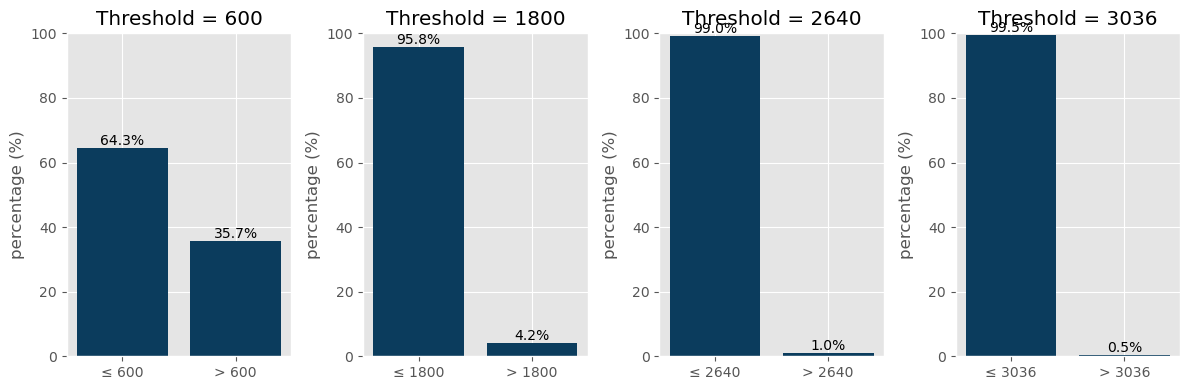

In [45]:
arr = np.array([4.08e-07, 5.45e+02, 7.12e+02, 2.45e+02, 4.03e+02, 1.53e+02])  # replace

thresholds = [600, 1800, 2640,3036]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, t in zip(axes, thresholds):
    count_le = np.sum(dt <= t)
    count_gt = np.sum(dt > t)
    total = len(dt)

    percentages = [
        100 * count_le / total,
        100 * count_gt / total
    ]

    labels = [f'≤ {t}', f'> {t}']
    bars = ax.bar(labels, percentages,color="#0b3c5d")

    ax.set_ylim(0, 100)
    ax.set_title(f"Threshold = {t}")
    ax.set_ylabel("percentage (%)")

    # annotate bars
    for bar, pct in zip(bars, percentages):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.savefig(OUT/"threshold_percentages.png", dpi=160)
plt.show()

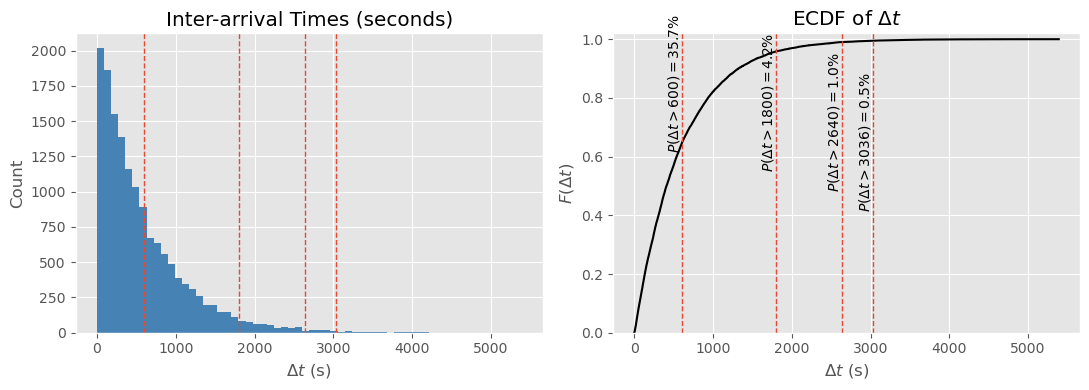

In [46]:
taus = [600, 1800, 2640,3036]
tau_labels = ["600", "1800", "2640","3036"]  # or ["10 min", "30 min", "44 min","51 min"]
fig, axes, exceed = plot_hist_and_ecdf_with_exceedance(dt, taus, tau_labels=tau_labels)
fig.savefig(OUT / "fig_data_hist_ecdf.png", dpi=160)
plt.show()

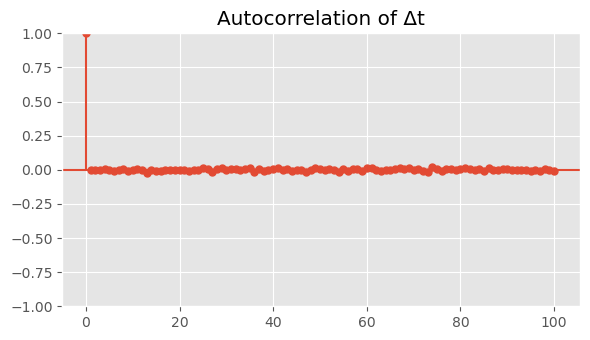

In [47]:
fig = plt.figure(figsize=(6,3.5))
sm.graphics.tsa.plot_acf(dt, lags=100, ax=plt.gca())
plt.title("Autocorrelation of Δt"); plt.tight_layout(); plt.savefig(OUT/"fig_acf.png", dpi=160)

In [48]:
"""ll = id_pois.posterior["ll_interval"]
id_pois.extend(az.from_dict(log_likelihood={"interval": ll}))

# 1) see what variable(s) exist in the group
print("log_likelihood vars:", list(id_pois["log_likelihood"].data_vars))

# 2) rename the (only) loglik variable to a common name "ll"
var = list(id_pois["log_likelihood"].data_vars)[0]   # should be "interval"
id_pois["log_likelihood"] = id_pois["log_likelihood"].rename({var: "ll"})

az.to_netcdf(id_pois, "models/poisson_model.nc") """

id_pois=az.from_netcdf("models/poisson_model.nc") 
print("renamed vars:", list(id_pois["log_likelihood"].data_vars))
print("dims:", id_pois["log_likelihood"]["ll"].dims)

renamed vars: ['ll']
dims: ('chain', 'draw', 'interval_dim_0')


In [49]:
summary = az.summary(id_pois, var_names=["lambda"])
summary
print(summary.to_latex(float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
lambda & 0.002 & 0.000 & 0.002 & 0.002 & 0.000 & 0.000 & 1623.000 & 2579.000 & 1.000 \\
\bottomrule
\end{tabular}



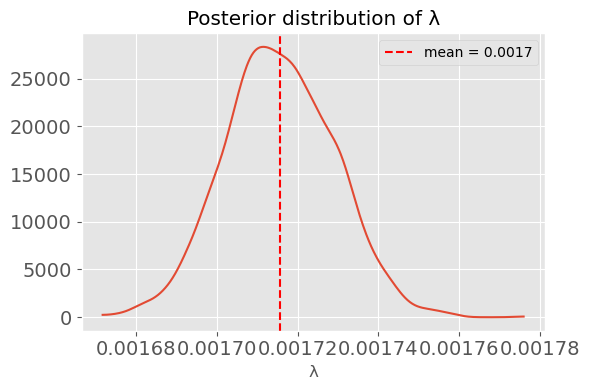

In [50]:
posterior = id_pois.posterior

# Extract samples
samples = posterior["lambda"].values.flatten()

# Plot
fig, ax = plt.subplots(figsize=(6,4))

az.plot_kde(samples, ax=ax)

mean_val = np.mean(samples)

ax.axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.4f}")

ax.set_title("Posterior distribution of λ")
ax.set_xlabel("λ")
ax.legend()

plt.tight_layout()
fig.savefig(OUT / "pois_lambda_posterior.png", dpi=160)
plt.show()

array([[<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>]], dtype=object)

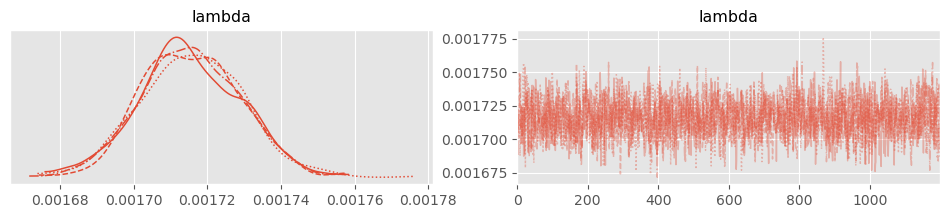

In [51]:
az.plot_trace(id_pois, var_names=["lambda"])

In [52]:
"""with pm.Model(coords=coords) as gam_m:
    dt_c = pm.Data("dt", dt, dims=["interval"])

    # Priors on Gamma shape and rate
    alpha = pm.Exponential("alpha", 1.0)      # shape > 0
    beta  = pm.Exponential("beta", 1.0)       # rate > 0  (1/scale)

    # Gamma likelihood; PyMC uses 'alpha' and 'beta' arguments
    y = pm.Gamma("y", alpha=alpha, beta=beta,
                 observed=dt_c, dims=["interval"])

    id_gamma = pm.sample(
        1200, tune=1200, chains=4,
        target_accept=0.95,
        return_inferencedata=True,
        init="adapt_diag",
        idata_kwargs={"log_likelihood": True},
        random_seed=42,
    )

# optional: alias log_likelihood key for consistency
id_gamma.log_likelihood["interval"] = id_gamma.log_likelihood["y"]
az.to_netcdf(id_gamma, "models/gamma_model.nc") """

id_gamma = az.from_netcdf("models/gamma_model.nc") 


In [53]:
summary = az.summary(id_gamma, var_names=["alpha","beta"])
summary
print(summary.to_latex(float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
alpha & 1.052 & 0.010 & 1.032 & 1.070 & 0.000 & 0.000 & 1423.000 & 1824.000 & 1.000 \\
beta & 0.002 & 0.000 & 0.002 & 0.002 & 0.000 & 0.000 & 1427.000 & 1763.000 & 1.000 \\
\bottomrule
\end{tabular}



In [54]:


latex_corr_table = corr.to_latex(
    float_format="%.2f",
    index=True,
    header=True,
    caption="Correlation matrix of numeric variables.",
    label="tab:corr_matrix",
    escape=False,
    longtable=False  # change to True if the table is wide
)

print(latex_corr_table)

\begin{table}
\caption{Correlation matrix of numeric variables.}
\label{tab:corr_matrix}
\begin{tabular}{lrrrrrrrr}
\toprule
 & tx_count & size & weight & difficulty & total_trans_fees & input_count & output_count & input_value \\
\midrule
tx_count & 1.00 & -0.12 & 0.13 & -0.38 & 0.20 & 0.00 & -0.00 & -0.01 \\
size & -0.12 & 1.00 & 0.35 & -0.03 & -0.11 & 0.16 & -0.07 & -0.09 \\
weight & 0.13 & 0.35 & 1.00 & 0.01 & 0.03 & 0.31 & 0.04 & 0.01 \\
difficulty & -0.38 & -0.03 & 0.01 & 1.00 & -0.07 & -0.11 & 0.04 & 0.04 \\
total_trans_fees & 0.20 & -0.11 & 0.03 & -0.07 & 1.00 & -0.06 & 0.08 & 0.08 \\
input_count & 0.00 & 0.16 & 0.31 & -0.11 & -0.06 & 1.00 & -0.04 & -0.06 \\
output_count & -0.00 & -0.07 & 0.04 & 0.04 & 0.08 & -0.04 & 1.00 & 1.00 \\
input_value & -0.01 & -0.09 & 0.01 & 0.04 & 0.08 & -0.06 & 1.00 & 1.00 \\
\bottomrule
\end{tabular}
\end{table}



array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

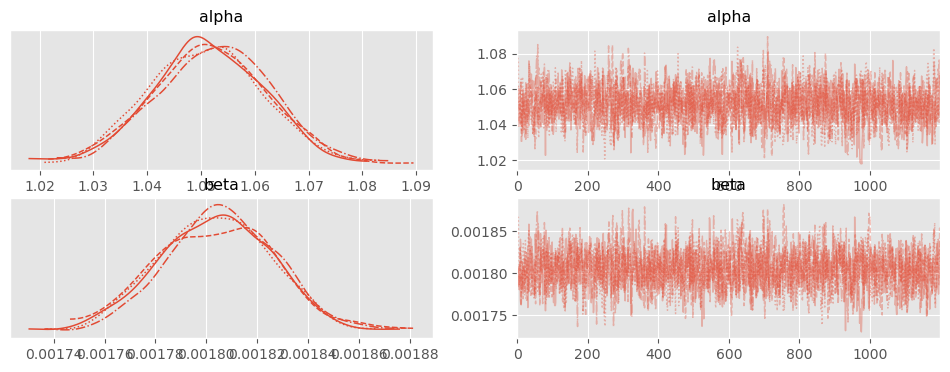

In [29]:
az.plot_trace(id_gamma, var_names=["alpha","beta"])

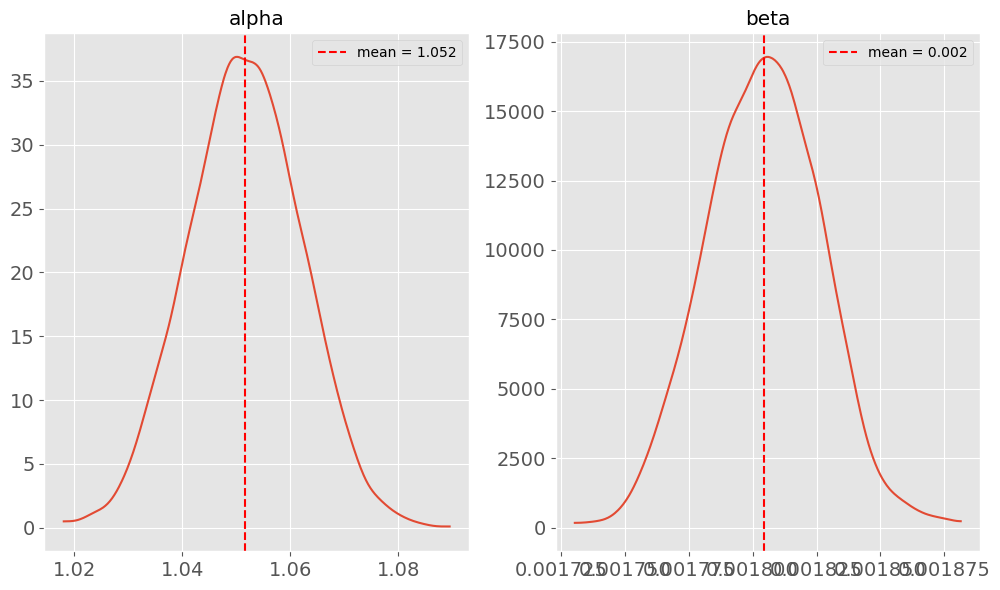

In [30]:
posterior = id_gamma.posterior

params = ["alpha","beta"]

fig, axes = plt.subplots(1, 2, figsize=(10,6))

axes = axes.flatten()

for i, p in enumerate(params):

    samples = posterior[p].values.flatten()
    
    az.plot_kde(samples, ax=axes[i])
    
    mean_val = np.mean(samples)
    
    axes[i].axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.3f}")
    
    axes[i].set_title(p)
    axes[i].legend()

plt.tight_layout()
fig.savefig(OUT / "gamma_posterior.png", dpi=160)
plt.show()

In [31]:
"""with pm.Model(coords=coords) as weib_m:
    dt_c = pm.Data("dt", dt, dims=["interval"])

    # Priors: shape k > 0, scale lambda > 0
    k       = pm.Exponential("k", 1.0)          # shape > 0
    lambda_ = pm.Exponential("lambda", 1.0)     # scale > 0

    # PyMC Weibull: alpha = shape, beta = scale
    y = pm.Weibull(
        "y",
        alpha=k,
        beta=lambda_,
        observed=dt_c,
        dims=["interval"],
    )

    id_weib = pm.sample(
        1200,
        tune=1200,
        chains=4,
        target_accept=0.95,
        return_inferencedata=True,
        init="adapt_diag",
        idata_kwargs={"log_likelihood": True},
        random_seed=42,
    )

# expose log-likelihood in a common name if you like
id_weib.log_likelihood["interval"] = id_weib.log_likelihood["y"]
az.to_netcdf(id_weib, "models/weib_model.nc") """

id_weib = az.from_netcdf("models/weib_model.nc") 

In [32]:
summary = az.summary(id_weib, var_names=["k","lambda"])
summary
print(summary.to_latex(float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
k & 1.018 & 0.006 & 1.006 & 1.030 & 0.000 & 0.000 & 2362.000 & 2227.000 & 1.000 \\
lambda & 566.457 & 4.635 & 558.050 & 575.273 & 0.095 & 0.071 & 2385.000 & 2462.000 & 1.000 \\
\bottomrule
\end{tabular}



array([[<Axes: title={'center': 'k'}>, <Axes: title={'center': 'k'}>],
       [<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>]], dtype=object)

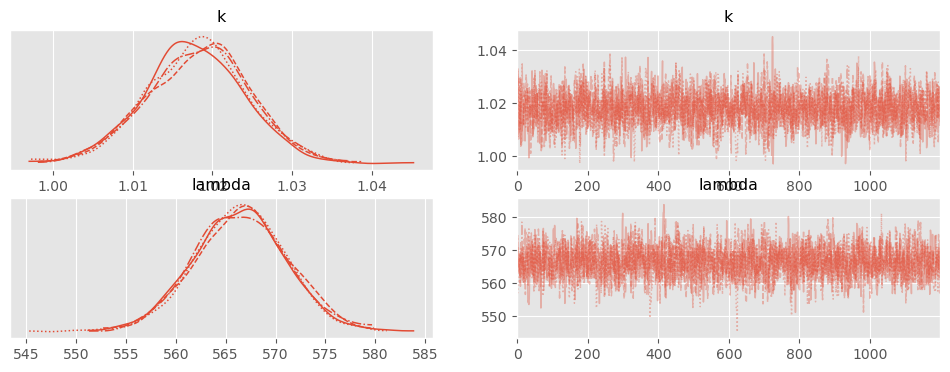

In [33]:
az.plot_trace(id_weib, var_names=["k","lambda"])

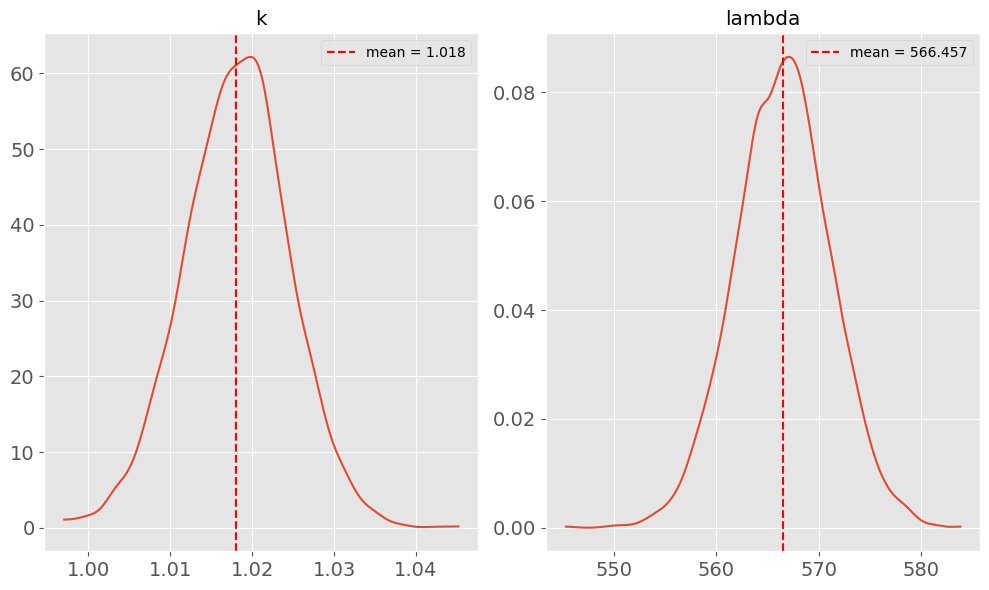

In [34]:
posterior = id_weib.posterior

params = ["k","lambda"]

fig, axes = plt.subplots(1, 2, figsize=(10,6))

axes = axes.flatten()

for i, p in enumerate(params):

    samples = posterior[p].values.flatten()
    
    az.plot_kde(samples, ax=axes[i])
    
    mean_val = np.mean(samples)
    
    axes[i].axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.3f}")
    
    axes[i].set_title(p)
    axes[i].legend()

plt.tight_layout()
fig.savefig(OUT / "weibull_posterior.png", dpi=160)
plt.show()

In [57]:
x_tx = zscore_safe(df['tx_count'])
x_size = zscore_safe(df['size'])
x_weight = zscore_safe(df['weight'])
x_diff = zscore_safe(df['difficulty'])
x_fees = zscore_safe(df['total_trans_fees'])
x_input_count = zscore_safe(df['input_count'])
x_output_count = zscore_safe(df['output_count'])

X = np.column_stack([
    np.asarray(x_tx,  float),
    np.asarray(x_size,    float),
    np.asarray(x_weight,  float),
    np.asarray(x_diff,float),
    np.asarray(x_fees, float),
    np.asarray(x_input_count,  float),
    np.asarray(x_output_count,  float),
])

#pd.DataFrame(X).head()

In [58]:
col_medians = np.nanmedian(X, axis=0)

In [59]:
X = np.where(np.isfinite(X), X, col_medians)

assert np.all(np.isfinite(X))

In [60]:
feat_names = ["diff","tx","size","weight","input","fees","output"]
#feat_names = ["diff","tx"]

# If your coords already exist, just ensure they include the 'feat' axis:
coords = {
    "interval": np.arange(len(dt)),
    "feat": feat_names,
}
p  = X.shape[1]   
t0 = time.time()
"""with pm.Model(coords={"interval": np.arange(N), "feat": np.arange(p)}) as ip_m:
    dt_c = pm.Data("dt", dt, dims=["interval"])
    X_c  = pm.Data("X",  X,  dims=["interval","feat"])

    beta0 = pm.Normal("beta0", 0., 1.)
    b     = pm.Normal("b", 0., 1., dims=["feat"])

    lin   = pm.math.clip(beta0 + pm.math.dot(X_c, b), -40, 40)
    lam   = pm.math.exp(lin)
    ll_i  = pm.math.log(lam) - lam * dt_c
    pm.Deterministic("ll_interval", ll_i, dims=["interval"])
    pm.Potential("sum_ll", ll_i.sum())

    id_ip = pm.sample(1200, tune=1200, chains=4, target_accept=0.9,
                      return_inferencedata=True, init="adapt_diag", random_seed=42)

# Expose pointwise log-lik for ArviZ (idempotent)
try:
    id_ip.add_groups({"log_likelihood": {"interval": id_ip.posterior["ll_interval"]}})
except ValueError:
    # group exists -> just assign/overwrite the variable
    id_ip.log_likelihood["interval"] = id_ip.posterior["ll_interval"]
    
az.to_netcdf(id_ip, "models/ipp_model.nc")"""
id_ip = az.from_netcdf("models/ipp_model.nc")

In [61]:
id_ip.log_likelihood["ll"] = id_ip.log_likelihood["interval"]

In [62]:
summary = az.summary(
    id_ip,
    var_names=["beta0", "b"],
    round_to=3
)
summary
print(summary.to_latex(float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
beta0 & -6.233 & 0.008 & -6.249 & -6.218 & 0.000 & 0.000 & 8662.589 & 3669.623 & 1.001 \\
b[0] & 0.022 & 0.011 & 0.001 & 0.043 & 0.000 & 0.000 & 6102.170 & 4033.795 & 1.000 \\
b[1] & 0.173 & 0.011 & 0.153 & 0.195 & 0.000 & 0.000 & 5976.237 & 3669.221 & 1.000 \\
b[2] & -0.195 & 0.010 & -0.214 & -0.176 & 0.000 & 0.000 & 5547.623 & 4049.546 & 1.000 \\
b[3] & 0.031 & 0.009 & 0.015 & 0.048 & 0.000 & 0.000 & 7038.660 & 4011.457 & 1.000 \\
b[4] & -0.240 & 0.019 & -0.276 & -0.204 & 0.000 & 0.000 & 7066.022 & 3994.799 & 1.001 \\
b[5] & 0.185 & 0.010 & 0.165 & 0.202 & 0.000 & 0.000 & 7899.683 & 3790.125 & 1.000 \\
b[6] & -0.511 & 0.013 & -0.536 & -0.489 & 0.000 & 0.000 & 7505.537 & 3884.064 & 1.000 \\
\bottomrule
\end{tabular}



In [40]:
feat_vals = id_ip.posterior["b"].coords["feat"].values
new_labels = [f"b[{i}]" for i in feat_vals]

# Assign new coordinate labels
id_ip.posterior = id_ip.posterior.assign_coords(feat=new_labels)

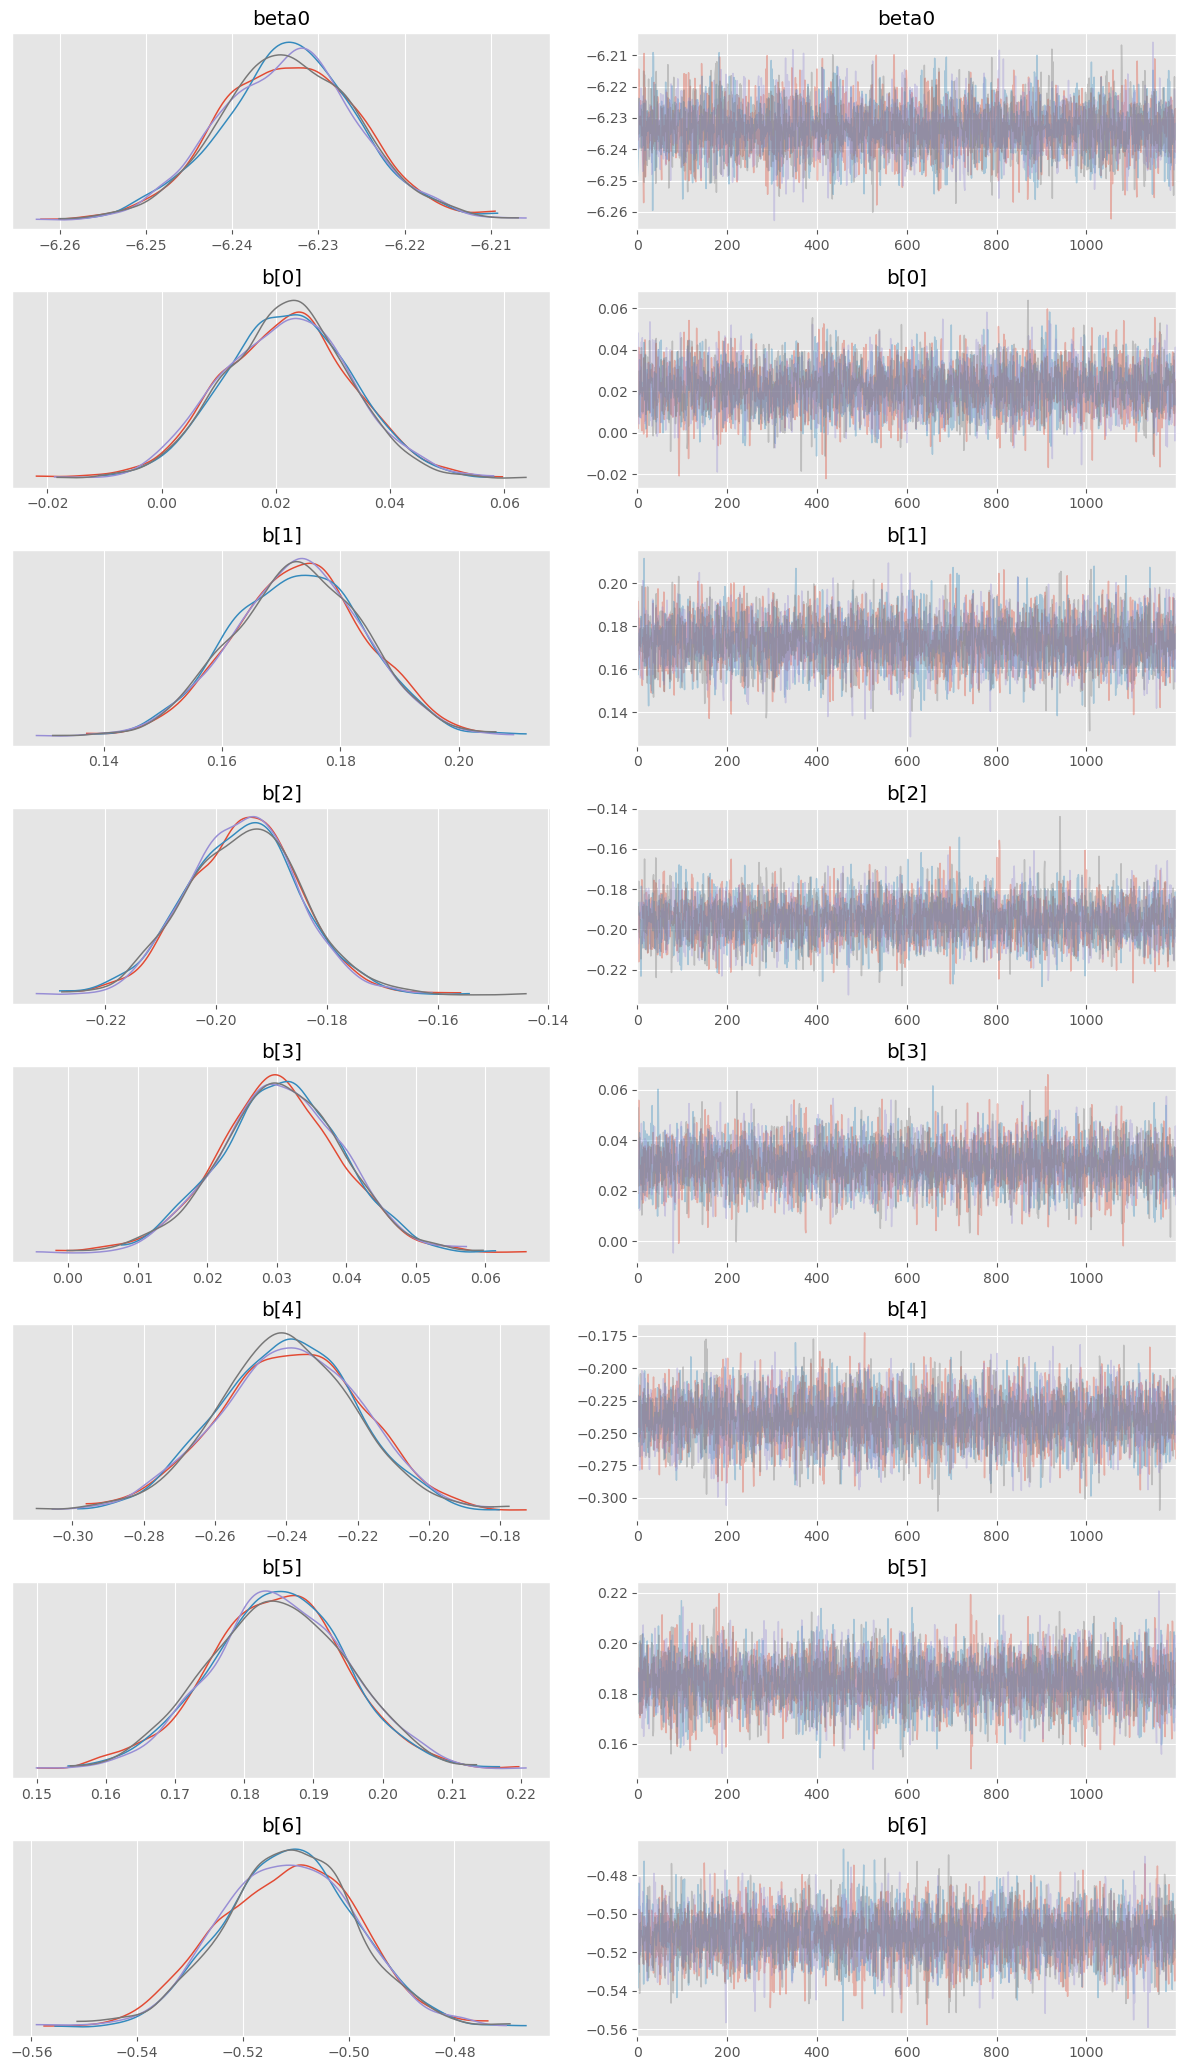

In [41]:
feat_vals = id_ip.posterior["b"].coords["feat"].values

axes = az.plot_trace(
    id_ip,
    var_names=["beta0", "b"],
    coords={"feat": feat_vals},
    compact=False,
    figsize=(12, 2.6 * (1 + len(feat_vals)))
)

axes = np.atleast_2d(axes)

# beta0 row
axes[0, 0].set_title("beta0")
axes[0, 1].set_title("beta0")

# b rows
for i, feat in enumerate(feat_vals, start=1):
    label = str(feat)   # <- use directly, do not wrap again
    axes[i, 0].set_title(label)
    axes[i, 1].set_title(label)

for row in axes:
    for ax in row:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [33]:
posterior = id_ip.posterior

# Build a flat list of parameter names to plot
b_size = posterior["b"].shape[-1]   # should be 7
param_specs = [("beta0", None)] + [("b", j) for j in range(b_size)]

# Layout: 8 parameters -> 3x3 grid leaves one empty
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (p, j) in enumerate(param_specs):
    if j is None:
        samples = posterior[p].values.flatten()
        title = p
    else:
        samples = posterior[p].values[..., j].flatten()
        title = f"{p}[{j}]"

    az.plot_kde(samples, ax=axes[i])

    mean_val = np.mean(samples)
    axes[i].axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.3f}")

    axes[i].set_title(title)reg_posterior
    axes[i].legend()

# Hide any unused subplot(s)
for k in range(len(param_specs), len(axes)):
    axes[k].axis("off")

plt.tight_layout()
fig.savefig(OUT / "reg_posterior.png", dpi=160)
plt.show()

SyntaxError: invalid syntax (959010545.py, line 24)

In [65]:
"""t0=time.time()
with pm.Model(coords=coords) as hawkes_m:
    dt_c  = pm.Data("dt", dt, dims=["interval"])
    mu    = pm.HalfNormal("mu", 1.0)
    beta  = pm.HalfNormal("beta", 1.0)
    rho   = pm.Beta("rho", 2, 5)
    alpha = pm.Deterministic("alpha", rho*beta)

    # optional soft stationarity constraint (alpha/beta < 1)
    pm.Potential("stability", pm.math.switch(alpha/beta < 0.98, 0.0, -np.inf))

    ll_i = hawkes_ll_interval_pt(dt_c, mu, alpha, beta)
    pm.Deterministic("ll_interval", ll_i, dims=["interval"])
    pm.Potential("sum_ll", ll_i.sum())

    # Use Metropolis for robustness (no gradients through scan)
    id_hawkes = pm.sample(1200, tune=1200, chains=4, step=pm.Metropolis(),
                          return_inferencedata=True, init="adapt_diag",idata_kwargs={"log_likelihood": True}, random_seed=42)

#id_hawkes.log_likelihood["interval"] = id_hawkes.posterior["ll_interval"]
id_hawkes.add_groups({"log_likelihood": {"interval": id_hawkes.posterior["ll_interval"]}})
 """
#runtime_s=time.time()-t0
t0=time.time()
with pm.Model(coords=coords) as hawkes_m_stationary:

    dt_c = pm.Data(
        "dt",
        dt,
        dims=["interval"]
    )

    mu = pm.HalfNormal(
        "mu",
        1.0
    )

    beta = pm.HalfNormal(
        "beta",
        1.0
    )

    # Natural stationarity constraint:
    # Beta prior already guarantees 0 < rho < 1
    rho = pm.Beta(
        "rho",
        2,
        5
    )

    alpha = pm.Deterministic(
        "alpha",
        rho * beta
    )

    # NO additional rho < 0.98 constraint

    ll_i = hawkes_ll_interval_pt(
        dt_c,
        mu,
        alpha,
        beta
    )

    pm.Deterministic(
        "ll_interval",
        ll_i,
        dims=["interval"]
    )

    pm.Potential(
        "sum_ll",
        ll_i.sum()
    )

    id_hawkes_stationary = pm.sample(
        1200,
        tune=1200,
        chains=4,
        step=pm.Metropolis(),
        return_inferencedata=True,
        init="adapt_diag",
        idata_kwargs={"log_likelihood": True},
        random_seed=42
    )


id_hawkes_stationary.add_groups({
    "log_likelihood": {
        "interval":
        id_hawkes_stationary.posterior["ll_interval"]
    }
})
runtime_s=time.time()-t0

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [mu]
>Metropolis: [beta]
>Metropolis: [rho]
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


Output()

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/pymc/step_methods/metropolis.py:321: RuntimeWarning: overflow encountered in exp
  "accept": np.mean(np.exp(self.accept_rate_iter)),


Sampling 4 chains for 1_200 tune and 1_200 draw iterations (4_800 + 4_800 draws total) took 1054 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [66]:
id_hawkes_stationary.to_netcdf(
    "models/hawkes_stationarity_rho_lt_1.nc"
)

'models/hawkes_stationarity_rho_lt_1.nc'

In [67]:
summary_original = az.summary(
    id_hawkes,
    var_names=["mu", "alpha", "beta", "rho"],
    hdi_prob=0.94,
    round_to=6
)

summary_stationary = az.summary(
    id_hawkes_stationary,
    var_names=["mu", "alpha", "beta", "rho"],
    hdi_prob=0.94,
    round_to=6
)

print("ORIGINAL: rho < 0.98")
display(summary_original)

print("NATURAL STATIONARITY: rho < 1")
display(summary_stationary)

ORIGINAL: rho < 0.98


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001001,0.000015,0.000974,0.001028,0.000001,0.000000,320.902211,413.778585,1.011832
alpha,0.005105,0.000126,0.004878,0.005339,0.000007,0.000004,322.538691,423.276525,1.010780
beta,0.005211,0.000129,0.004982,0.005456,0.000007,0.000004,324.018831,423.276525,1.009631
rho,0.979595,0.000394,0.978866,0.979999,0.000020,0.000020,319.493117,255.253734,1.014799


NATURAL STATIONARITY: rho < 1


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.001630,0.000073,0.001487,0.001733,0.000031,0.000018,6.324716,14.520400,1.747255
alpha,0.000008,0.000025,0.000000,0.000024,0.000003,0.000006,30.154290,119.733797,1.107658
beta,0.017154,0.117339,0.000000,0.009123,0.009850,0.034162,12.730879,70.083536,1.254099
rho,0.051160,0.043483,0.000029,0.129192,0.017677,0.010106,6.803775,23.210564,1.677976


In [ ]:
az.to_netcdf(id_hawkes, "models/hawkes_model.nc")

In [ ]:
id_hawkes =  az.from_netcdf("models/hawkes_model.nc")

In [35]:
#id_hawkes =  az.from_netcdf("models/hawkes_model_nut.nc")

In [45]:
summary = az.summary(id_hawkes, var_names=["mu","alpha","beta","rho"])
summary
print(summary.to_latex(float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
mu & 0.001 & 0.000 & 0.001 & 0.001 & 0.000 & 0.000 & 321.000 & 414.000 & 1.010 \\
alpha & 0.005 & 0.000 & 0.005 & 0.005 & 0.000 & 0.000 & 323.000 & 423.000 & 1.010 \\
beta & 0.005 & 0.000 & 0.005 & 0.005 & 0.000 & 0.000 & 324.000 & 423.000 & 1.010 \\
rho & 0.980 & 0.000 & 0.979 & 0.980 & 0.000 & 0.000 & 319.000 & 255.000 & 1.010 \\
\bottomrule
\end{tabular}



array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>]],
      dtype=object)

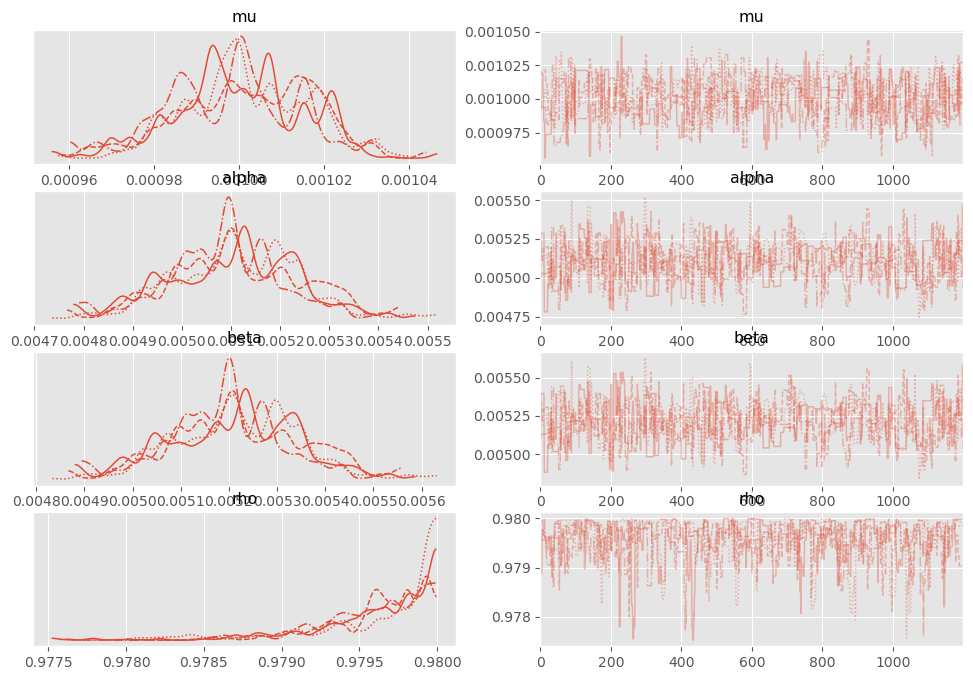

In [46]:
az.plot_trace(id_hawkes, var_names=["mu","alpha","beta","rho"])

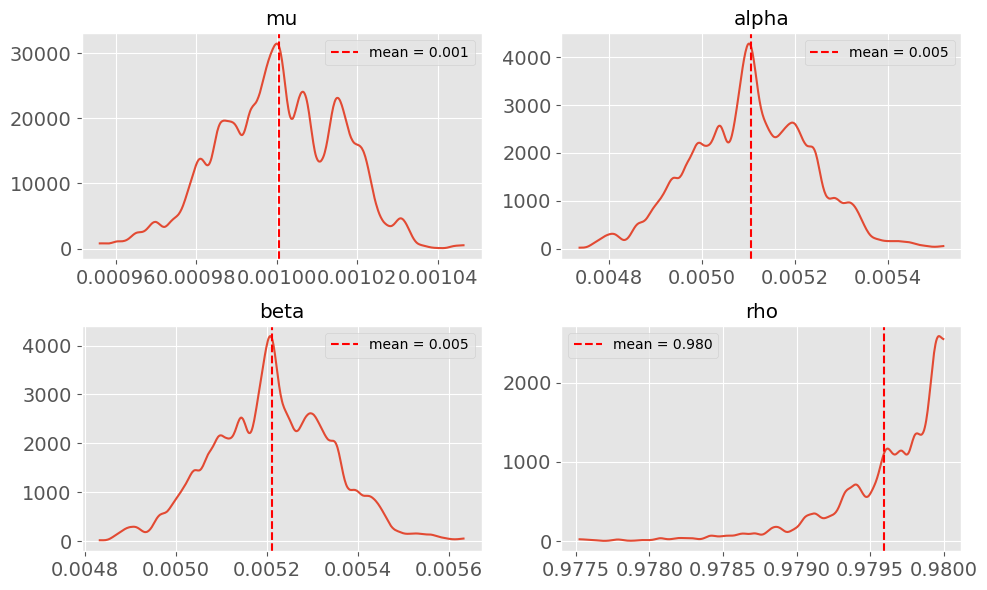

In [47]:
posterior = id_hawkes.posterior

params = ["mu", "alpha", "beta", "rho"]

fig, axes = plt.subplots(2, 2, figsize=(10,6))

axes = axes.flatten()

for i, p in enumerate(params):

    samples = posterior[p].values.flatten()
    
    az.plot_kde(samples, ax=axes[i])
    
    mean_val = np.mean(samples)
    
    axes[i].axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.3f}")
    
    axes[i].set_title(p)
    axes[i].legend()

plt.tight_layout()
fig.savefig(OUT / "hawkes_posterior.png", dpi=160)
plt.show()

In [48]:
"""_, id_hawkes_exog, _, _ = functions.fit_hawkes_covariates(dt, X, feature_names=feat_names)

# Reuse your working ArviZ pattern
id_hawkes_exog.extend(
    az.from_dict(log_likelihood={"ll": id_hawkes_exog.posterior["ll_interval"]})
)"""

'_, id_hawkes_exog, _, _ = functions.fit_hawkes_covariates(dt, X, feature_names=feat_names)\n\n# Reuse your working ArviZ pattern\nid_hawkes_exog.extend(\n    az.from_dict(log_likelihood={"ll": id_hawkes_exog.posterior["ll_interval"]})\n)'

In [49]:
#az.to_netcdf(id_hawkes_exog, "models/hawkes_exog_model.nc")

In [74]:
id_hawkes_exog=az.from_netcdf("models/hawkes_exog_model.nc") 
#print(id_hawkes_exog.log_likelihood)

In [36]:
summary = az.summary(
    id_hawkes_exog,
    var_names=["intercept", "beta_x", "rho", "decay", "alpha"],
    round_to=6
)
summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-8.485409,0.085922,-8.655012,-8.329340,0.001898,0.001257,2051.255345,2439.448233,1.001857
beta_x[diff],-0.062109,0.016591,-0.093873,-0.030647,0.000292,0.000220,3240.738153,3126.543731,1.001757
beta_x[tx],0.022306,0.014741,-0.004313,0.049750,0.000259,0.000202,3246.642592,3183.430753,1.000475
beta_x[size],-0.043731,0.012315,-0.067251,-0.021125,0.000242,0.000167,2591.028908,2533.710316,1.004396
beta_x[weight],0.067576,0.016886,0.035868,0.098843,0.000291,0.000220,3364.813673,3540.165944,1.002077
beta_x[input],-0.758771,0.081727,-0.914477,-0.608573,0.001232,0.001179,4451.570801,3231.356922,1.000822
beta_x[fees],0.106086,0.012135,0.084370,0.129750,0.000187,0.000164,4220.170158,3449.605203,1.001798
beta_x[output],-4.474770,0.145160,-4.753274,-4.206050,0.003164,0.002167,2099.808911,2669.553072,1.001506
rho,0.583685,0.009808,0.566498,0.603319,0.000185,0.000130,2790.070782,3190.522878,1.001518
decay,0.000010,0.000001,0.000008,0.000013,0.000000,0.000000,4598.368125,3193.573806,1.001256


In [38]:

print(summary.to_latex(float_format="%.6f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
intercept & -8.485409 & 0.085922 & -8.655012 & -8.329340 & 0.001898 & 0.001257 & 2051.255345 & 2439.448233 & 1.001857 \\
beta_x[diff] & -0.062109 & 0.016591 & -0.093873 & -0.030647 & 0.000292 & 0.000220 & 3240.738153 & 3126.543731 & 1.001757 \\
beta_x[tx] & 0.022306 & 0.014741 & -0.004313 & 0.049750 & 0.000259 & 0.000202 & 3246.642592 & 3183.430753 & 1.000475 \\
beta_x[size] & -0.043731 & 0.012315 & -0.067251 & -0.021125 & 0.000242 & 0.000167 & 2591.028908 & 2533.710316 & 1.004396 \\
beta_x[weight] & 0.067576 & 0.016886 & 0.035868 & 0.098843 & 0.000291 & 0.000220 & 3364.813673 & 3540.165944 & 1.002077 \\
beta_x[input] & -0.758771 & 0.081727 & -0.914477 & -0.608573 & 0.001232 & 0.001179 & 4451.570801 & 3231.356922 & 1.000822 \\
beta_x[fees] & 0.106086 & 0.012135 & 0.084370 & 0.129750 & 0.000187 & 0.000164 & 4220.170158 & 3449.605203 & 1.001798 \\
beta_x[ou

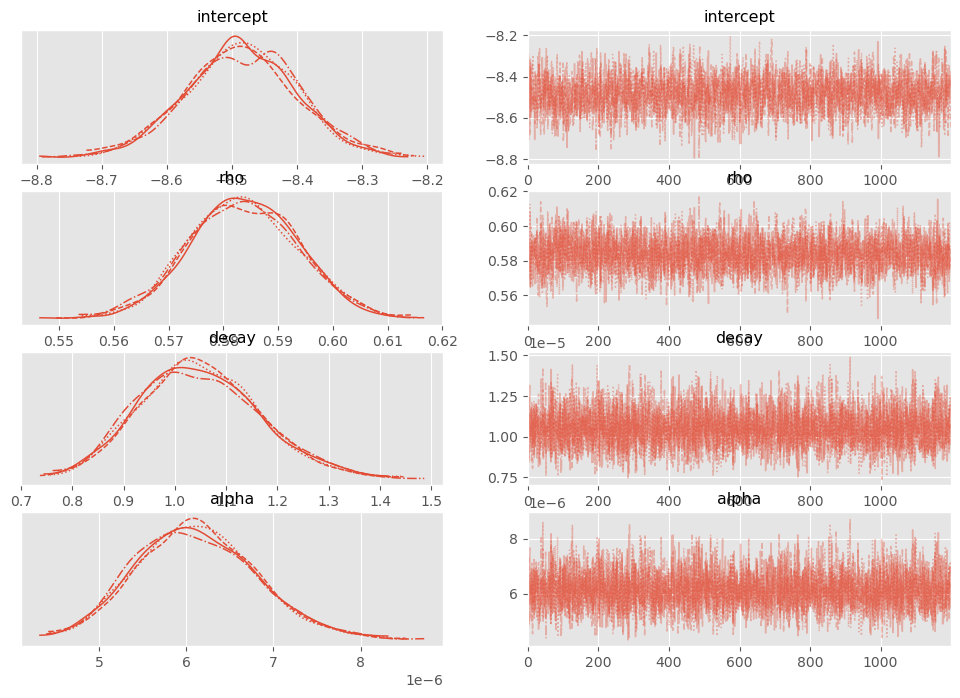

In [53]:
az.plot_trace(id_hawkes_exog, var_names=["intercept", "rho", "decay", "alpha"]);
#az.plot_pair(id_hawkes_exog, var_names=["rho", "decay", "intercept"], kind="kde");

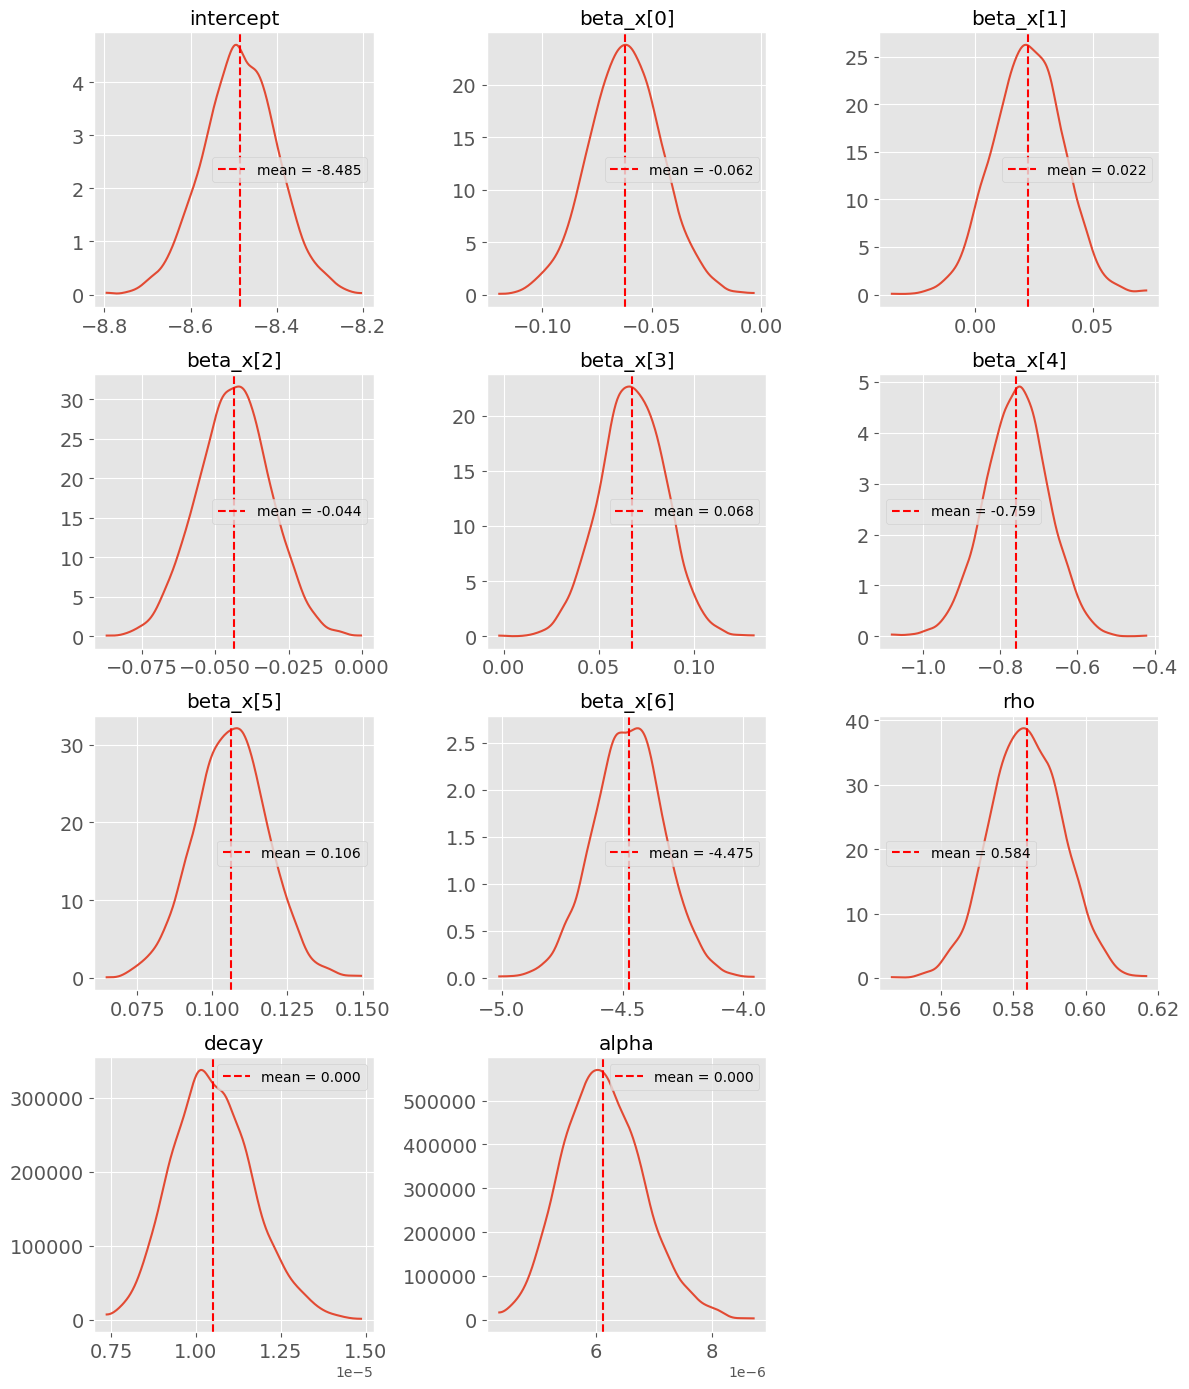

In [54]:
posterior = id_hawkes_exog.posterior

# How many covariate coefficients?
beta_size = posterior["beta_x"].shape[-1]

# Build list of parameters to plot
param_specs = [("intercept", None)] + [("beta_x", j) for j in range(beta_size)] + [("rho", None), ("decay", None), ("alpha", None)]

n_params = len(param_specs)
ncols = 3
nrows = int(np.ceil(n_params / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, (p, j) in enumerate(param_specs):
    if j is None:
        samples = posterior[p].values.flatten()
        title = p
    else:
        samples = posterior[p].values[..., j].flatten()
        title = f"{p}[{j}]"

    az.plot_kde(samples, ax=axes[i])

    mean_val = np.mean(samples)
    axes[i].axvline(mean_val, color="red", linestyle="--", label=f"mean = {mean_val:.3f}")

    axes[i].set_title(title)
    axes[i].legend()

# Turn off unused axes
for k in range(n_params, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
fig.savefig(OUT / "hawkes_cov_posterior.png", dpi=160)
plt.show()

In [55]:
'''powerlaw_model, powerlaw_idata, X_mean_pl, X_std_pl, rate_grid = (
    fit_powerlaw_hawkes_covariates(
        dt=dt,
        X=X,
        feature_names=feat_names,
        draws=1200,
        tune=1200,
        chains=4,
        target_accept=0.95,
        random_seed=42,
        n_basis=12,
    )
) '''



'powerlaw_model, powerlaw_idata, X_mean_pl, X_std_pl, rate_grid = (\n    fit_powerlaw_hawkes_covariates(\n        dt=dt,\n        X=X,\n        feature_names=feat_names,\n        draws=1200,\n        tune=1200,\n        chains=4,\n        target_accept=0.95,\n        random_seed=42,\n        n_basis=12,\n    )\n) '

In [56]:
'''powerlaw_idata.to_netcdf(
    "models/powerlaw_hawkes_covariates_idata.nc"
)'''

'powerlaw_idata.to_netcdf(\n    "models/powerlaw_hawkes_covariates_idata.nc"\n)'

In [57]:
np.savez(
    "models/powerlaw_hawkes_covariates_metadata.npz",
    X_mean=X_mean_pl,
    X_std=X_std_pl,
    rate_grid=rate_grid
)

NameError: name 'X_mean_pl' is not defined

In [58]:
powerlaw_idata = az.from_netcdf(
    "models/powerlaw_hawkes_covariates_idata.nc"
)

In [59]:
summary_power_law = az.summary(
    powerlaw_idata,
    var_names=[
        "intercept",
        "beta_x",
        "rho",
        "power",
        "kernel_shift",
    ],
    hdi_prob=0.94,
    round_to=6
)
summary_power_law

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-8.482512,0.087799,-8.652553,-8.328747,0.001751,0.001199,2514.758247,3139.773662,1.001680
beta_x[diff],-0.064903,0.016328,-0.095078,-0.034950,0.000292,0.000206,3123.688274,3189.698692,1.001102
beta_x[tx],0.021055,0.014887,-0.006776,0.048508,0.000246,0.000197,3667.233836,3696.511953,1.000560
beta_x[size],-0.041981,0.012712,-0.065470,-0.016950,0.000233,0.000161,2980.123146,3159.818109,1.000994
beta_x[weight],0.058676,0.017067,0.024773,0.088733,0.000305,0.000220,3129.402387,3268.852826,1.001672
beta_x[input],-0.776145,0.083159,-0.929301,-0.619915,0.001281,0.001131,4261.721249,3515.283191,1.000408
beta_x[fees],0.105325,0.012422,0.081698,0.128680,0.000200,0.000178,3871.875233,3403.816377,1.000882
beta_x[output],-4.462265,0.147621,-4.732125,-4.184041,0.002898,0.002030,2591.167004,3059.796919,1.001945
rho,0.590429,0.010396,0.570245,0.608998,0.000183,0.000123,3225.103282,3653.317843,1.000520
power,2.810065,0.574507,1.873207,3.843869,0.011270,0.010753,2546.936559,3158.338387,1.000957


In [60]:
print(summary_power_law.to_latex(float_format="%.6f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi_3% & hdi_97% & mcse_mean & mcse_sd & ess_bulk & ess_tail & r_hat \\
\midrule
intercept & -8.482512 & 0.087799 & -8.652553 & -8.328747 & 0.001751 & 0.001199 & 2514.758247 & 3139.773662 & 1.001680 \\
beta_x[diff] & -0.064903 & 0.016328 & -0.095078 & -0.034950 & 0.000292 & 0.000206 & 3123.688274 & 3189.698692 & 1.001102 \\
beta_x[tx] & 0.021055 & 0.014887 & -0.006776 & 0.048508 & 0.000246 & 0.000197 & 3667.233836 & 3696.511953 & 1.000560 \\
beta_x[size] & -0.041981 & 0.012712 & -0.065470 & -0.016950 & 0.000233 & 0.000161 & 2980.123146 & 3159.818109 & 1.000994 \\
beta_x[weight] & 0.058676 & 0.017067 & 0.024773 & 0.088733 & 0.000305 & 0.000220 & 3129.402387 & 3268.852826 & 1.001672 \\
beta_x[input] & -0.776145 & 0.083159 & -0.929301 & -0.619915 & 0.001281 & 0.001131 & 4261.721249 & 3515.283191 & 1.000408 \\
beta_x[fees] & 0.105325 & 0.012422 & 0.081698 & 0.128680 & 0.000200 & 0.000178 & 3871.875233 & 3403.816377 & 1.000882 \\
beta_x[ou

In [61]:
exp_loo_idata = prepare_loglik_for_loo(
    id_hawkes_exog,
    ll_var="ll_interval",
    obs_name="obs"
)

powerlaw_loo_idata = prepare_loglik_for_loo(
    powerlaw_idata,
    ll_var="ll_interval",
    obs_name="obs"
)

ll_interval dims : ('chain', 'draw', 'interval')
ll_interval shape: (4, 1200, 15000)
ll_interval dims : ('chain', 'draw', 'interval')
ll_interval shape: (4, 1200, 15000)


In [62]:
loo_exp = az.loo(
    exp_loo_idata,
    var_name="obs",
    pointwise=True
)

loo_powerlaw = az.loo(
    powerlaw_loo_idata,
    var_name="obs",
    pointwise=True
)

print("\nEXPONENTIAL HAWKES + COVARIATES")
print(loo_exp)

print("\nPOWER-LAW HAWKES + COVARIATES")
print(loo_powerlaw)

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



EXPONENTIAL HAWKES + COVARIATES
Computed from 4800 posterior samples and 15000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -107187.00   131.58
p_loo       13.78        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     14999  100.0%
   (0.70, 1]   (bad)          1    0.0%
   (1, Inf)   (very bad)     0    0.0%


POWER-LAW HAWKES + COVARIATES
Computed from 4800 posterior samples and 15000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -107194.59   131.70
p_loo       15.27        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     14999  100.0%
   (0.70, 1]   (bad)          0    0.0%
   (1, Inf)   (very bad)     1    0.0%



In [63]:
loo_compare = az.compare(
    {
        "Hawkes + covariates (Exponential)": exp_loo_idata,
        "Hawkes + covariates (Power-law)": powerlaw_loo_idata,
    },
    ic="loo",
    method="stacking"
)

loo_compare

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Hawkes + covariates (Exponential),0,-107186.997190,13.778906,0.000000,1.000000e+00,131.578558,0.000000,True,log
Hawkes + covariates (Power-law),1,-107194.587734,15.270083,7.590544,5.384582e-15,131.703235,1.632661,True,log


In [64]:
k_exp = np.asarray(loo_exp.pareto_k)
k_pl  = np.asarray(loo_powerlaw.pareto_k)

idx_exp = np.argmax(k_exp)
idx_pl  = np.argmax(k_pl)

print("Exponential")
print("index:", idx_exp)
print("Pareto k:", k_exp[idx_exp])
print("dt:", dt[idx_exp])

print("\nPower-law")
print("index:", idx_pl)
print("Pareto k:", k_pl[idx_pl])
print("dt:", dt[idx_pl])

Exponential
index: 6002
Pareto k: 0.9445123391677451
dt: 1305.0

Power-law
index: 6002
Pareto k: 1.28060751784051
dt: 1305.0


In [65]:
print("Maximum observed dt:", np.max(dt))
print("Index of maximum dt:", np.argmax(dt))

Maximum observed dt: 5389.0
Index of maximum dt: 4345


In [66]:
# Pointwise PSIS-LOO contributions
loo_i_exp = np.asarray(loo_exp.loo_i)
loo_i_pl  = np.asarray(loo_powerlaw.loo_i)

bad_idx = 6002

# ELPD excluding the common influential observation
elpd_exp_without = loo_i_exp.sum() - loo_i_exp[bad_idx]
elpd_pl_without  = loo_i_pl.sum()  - loo_i_pl[bad_idx]

delta_without = elpd_exp_without - elpd_pl_without

print("Exponential ELPD excluding obs 6002:", elpd_exp_without)
print("Power-law ELPD excluding obs 6002:", elpd_pl_without)
print("ΔELPD Exp - PL excluding obs 6002:", delta_without)

# How much does obs 6002 itself favour either model?
delta_obs = loo_i_exp[bad_idx] - loo_i_pl[bad_idx]

print("\nObservation 6002:")
print("Exp LOO contribution:", loo_i_exp[bad_idx])
print("PL LOO contribution :", loo_i_pl[bad_idx])
print("Difference           :", delta_obs)

Exponential ELPD excluding obs 6002: -107161.98121754956
Power-law ELPD excluding obs 6002: -107168.69832971736
ΔELPD Exp - PL excluding obs 6002: 6.717112167796586

Observation 6002:
Exp LOO contribution: -25.015972383173327
PL LOO contribution : -25.889404282790725
Difference           : 0.8734318996173975


In [67]:
#times = np.asarray(times_data, float)
times = np.sort(times)  
assert np.all(np.diff(times) > 0), "times_data must be strictly increasing"
T_last = times[-1]


X_future = np.asarray(X[-1], float)   

In [68]:
X_no_nan = X[np.all(np.isfinite(X), axis=1)]
X_future = X_no_nan[-1] if len(X_no_nan) else np.nan_to_num(X[-1], nan=0.0)

taus = [600, 900, 1200]
ex_ip = ip_exceed(id_ip, X_future, taus)
print("IP tail exceedance P(Δt>τ):", dict(zip(taus, ex_ip)))

IP tail exceedance P(Δt>τ): {600: 0.16992839796779338, 900: 0.0700979372114506, 1200: 0.0289299815411576}


In [69]:
#times = np.asarray(times_data, float)
assert np.all(np.diff(times) > 0), "times_data must be strictly increasing"
T_last = times[-1]
taus = np.linspace(0, 3600, 121)  # 0..60 min, 30s step

# choose a covariate row for IP/Hawkes+X "now" prediction (e.g., last available)
X_future = np.asarray(X[-1], float)   # shape (p,)

In [70]:
times

array([0.000000e+00, 5.450000e+02, 1.257000e+03, ..., 8.742221e+06,
       8.742624e+06, 8.742777e+06])

In [71]:
times_seconds = to_seconds(times)

In [39]:
times_seconds

array([0.000000e+00, 5.450000e+02, 1.257000e+03, ..., 8.742221e+06,
       8.742624e+06, 8.742777e+06])

In [73]:
taus = np.linspace(0, 3600, 121)  

In [74]:
#s_emp, s_lo, s_hi = empirical_survival_with_ci(times, taus, alpha=0.10)
S_hx, b_hx  = S_hawkes_exog_new(id_hawkes_exog, X_future, times, taus) 
S_p,  b_p  = S_poisson(id_pois, taus)
S_ip_,b_ip = S_ip(id_ip, X_future, taus)
S_g,  b_g  = S_gamma(id_gamma, taus)
S_w,  b_w  = S_weibull(id_weib, taus)
S_h,  b_h  = S_hawkes(id_hawkes, times, taus)

In [75]:
times = to_seconds(arrival_interval)

In [76]:
times

array([ nan, 545., 712., ..., 245., 403., 153.])

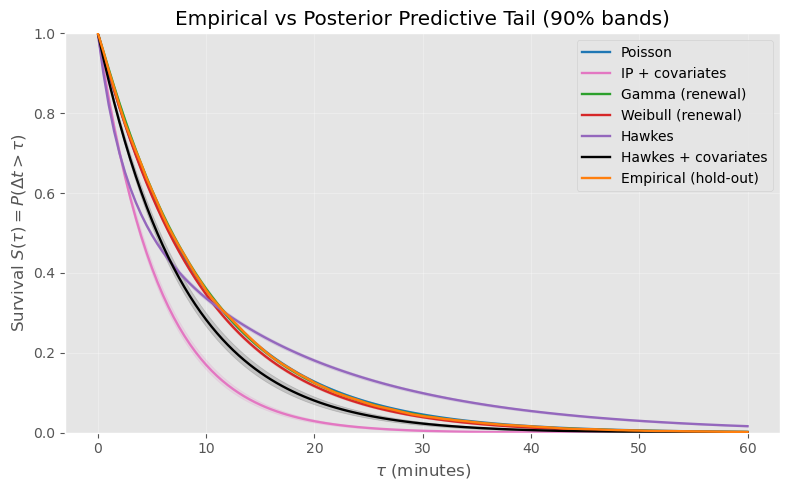

In [77]:
# times: your Δt array (seconds), same one you used in tail_loo(...)
# taus:  your τ grid (seconds)
#taus = np.linspace(0, 3600, 121) 
# 1) empirical survival + 90% CI (Wilson) using your earlier helper
s_emp, s_lo, s_hi = empirical_survival_with_ci(times, taus, alpha=0.10)

# 2) plot models first (your existing band() calls), then empirical on top
plt.figure(figsize=(8,5))

band(taus/60, b_p,  "Poisson",             "tab:blue")
band(taus/60, b_ip, "IP + covariates",     "tab:pink")
band(taus/60, b_g,  "Gamma (renewal)",     "tab:green")
band(taus/60, b_w,  "Weibull (renewal)",   "tab:red")
band(taus/60, b_h,  "Hawkes",              "tab:purple")
band(taus/60, b_hx, "Hawkes + covariates",  "black")
#band(taus/60, b_hx, "Hawkes + covariates",  colors["Hawkes + covariates"], ls="--", lw=2.2, alpha=0.18)


# empirical (hold-out) drawn last, bold, step style
# Empirical curve (now orange)
emp_color = "tab:orange"

plt.plot(
    taus/60,
    s_emp,
    lw=1.7,
    color=emp_color,
    zorder=10,
    label="Empirical (hold-out)"
)

plt.fill_between(
    taus/60,
    s_lo,
    s_hi,
    color=emp_color,
    alpha=0.15,
    linewidth=0,
    zorder=9
)

plt.xlabel(r"$\tau$ (minutes)")
plt.ylabel(r"Survival $S(\tau)=P(\Delta t>\tau)$")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Empirical vs Posterior Predictive Tail (90% bands)")
plt.tight_layout()
plt.savefig(OUT / "fig_posterior_tail_empirical.png", dpi=160)
plt.show()


In [78]:
dt_like = np.asarray(dt, float)

models_all = {
    "pois":   id_pois,
    "ip":     id_ip,
    "gamma":  id_gamma,
    "weib":   id_weib,
    "hawkes": id_hawkes,
    "hawkes_exog":id_hawkes_exog
}

In [79]:
tau600 = 600  # seconds

cmp_tail_600 = compare_tail_models(models_all, dt_like, tau600)

print(f"\nTail PSIS-LOO (Δt > {tau600:.0f} s)  -- higher elpd_loo is better\n")
display(cmp_tail_600)

Path("tables").mkdir(exist_ok=True)
(Path("tables")/"tailPSISI600s.tex").write_text(
    cmp_tail_600.to_latex(index=False, float_format="%.1f", escape=False,
                    caption=f"Tail PSIS-LOO (Δt > {int(tau600)} s)",
                    label="tab:tailPSISI600s")
)

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



Tail PSIS-LOO (Δt > 600 s)  -- higher elpd_loo is better



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hawkes_exog,0,-43805.383364,8.892583,0.000000,9.661103e-01,52.627349,0.000000,True,log
ip,1,-44377.206535,10.431967,571.823172,6.221750e-12,58.831013,36.676759,True,log
hawkes,2,-44511.245833,0.503546,705.862470,3.388968e-02,52.488669,39.497775,False,log
gamma,3,-44787.017446,0.935241,981.634082,5.982879e-11,73.015417,42.751064,False,log
pois,4,-44829.215922,0.660183,1023.832559,2.783610e-09,70.819410,41.216493,False,log
weib,5,-44999.310692,1.151161,1193.927328,5.873975e-09,75.073633,44.226432,False,log


619

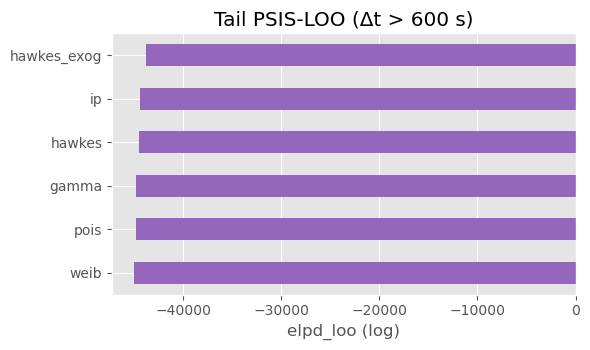

In [80]:
ax = cmp_tail_600.sort_values("elpd_loo")["elpd_loo"].plot.barh(figsize=(6,3.6), color="tab:purple")
ax.set_title(f"Tail PSIS-LOO (Δt > {int(tau600)} s)"); ax.set_xlabel("elpd_loo (log)")
plt.tight_layout();plt.savefig(OUT/"tailPSISI600s.png", dpi=160); plt.show()

In [81]:
tau1800 = 1800  # seconds

cmp_tail_1800 = compare_tail_models(models_all, dt_like, tau1800)

print(f"\nTail PSIS-LOO (Δt > {tau1800:.0f} s)  -- higher elpd_loo is better\n")
display(cmp_tail_1800)

Path("tables").mkdir(exist_ok=True)
(Path("tables")/"tailPSISI1800a.tex").write_text(
    cmp_tail_1800.to_latex(index=False, float_format="%.1f", escape=False,
                    caption=f"Tail PSIS-LOO (Δt > {int(tau1800)} s)",
                    label="tab:tailPSISI1800s")
)


Tail PSIS-LOO (Δt > 1800 s)  -- higher elpd_loo is better



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hawkes_exog,0,-5911.927863,0.954669,0.000000,0.729067,17.634919,0.000000,False,log
ip,1,-5963.110668,1.042603,51.182805,0.268923,20.000017,16.559870,False,log
hawkes,2,-6021.473673,0.265273,109.545810,0.002010,16.950791,14.039365,False,log
pois,3,-6564.653955,0.412869,652.726092,0.000000,23.747360,14.556689,False,log
gamma,4,-6602.335154,0.575834,690.407290,0.000000,24.716261,15.224373,False,log
weib,5,-6665.366903,0.728733,753.439040,0.000000,25.520923,15.802485,False,log


613

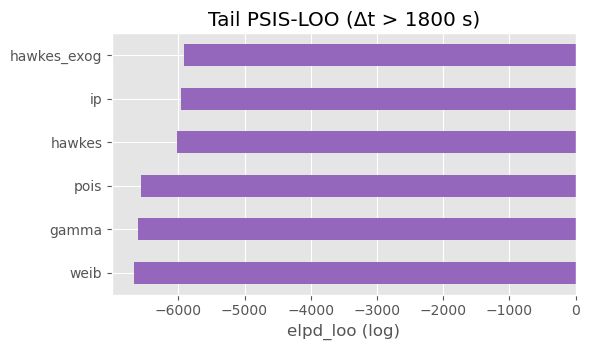

In [82]:
ax = cmp_tail_1800.sort_values("elpd_loo")["elpd_loo"].plot.barh(figsize=(6,3.6), color="tab:purple")
ax.set_title(f"Tail PSIS-LOO (Δt > {int(tau1800)} s)"); ax.set_xlabel("elpd_loo (log)")
plt.tight_layout();plt.savefig(OUT/"tailPSISI1800s.png", dpi=160); plt.show()

In [83]:
tau2640 = 2640  # seconds

cmp_tail_2640 = compare_tail_models(models_all, dt_like, tau2640)

print(f"\nTail PSIS-LOO (Δt > {tau2640:.0f} s)  -- higher elpd_loo is better\n")
display(cmp_tail_2640)

Path("tables").mkdir(exist_ok=True)
(Path("tables")/"tailPSISI2640s.tex").write_text(
    cmp_tail_2640.to_latex(index=False, float_format="%.1f", escape=False,
                    caption=f"Tail PSIS-LOO (Δt > {int(tau2640)} s)",
                    label="tab:tailPSISI2640s")
)


Tail PSIS-LOO (Δt > 2640 s)  -- higher elpd_loo is better



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
ip,0,-1465.708012,0.481375,0.000000,8.723116e-01,11.374874,0.000000,False,log
hawkes_exog,1,-1498.573225,0.407187,32.865213,9.784912e-02,8.233520,9.565492,False,log
hawkes,2,-1524.183766,0.139641,58.475755,2.983927e-02,7.580486,11.977679,False,log
pois,3,-1734.676820,0.192649,268.968808,1.503033e-11,10.279214,13.205721,False,log
gamma,4,-1751.829620,0.296083,286.121609,1.667792e-11,10.725230,13.458081,False,log
weib,5,-1773.427651,0.418336,307.719640,1.857735e-11,11.107789,13.682115,False,log


609

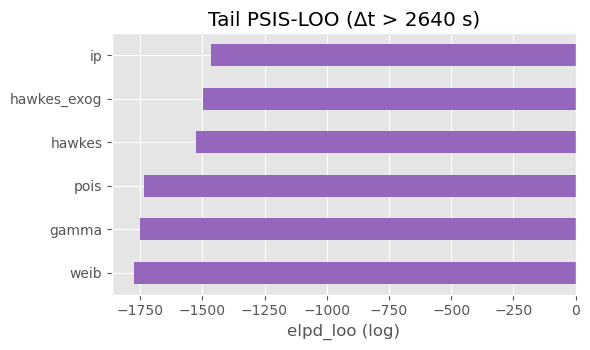

In [84]:
ax = cmp_tail_2640.sort_values("elpd_loo")["elpd_loo"].plot.barh(figsize=(6,3.6), color="tab:purple")
ax.set_title(f"Tail PSIS-LOO (Δt > {int(tau2640)} s)"); ax.set_xlabel("elpd_loo (log)")
plt.tight_layout();plt.savefig(OUT/"tailPSISI2640s.png", dpi=160); plt.show()

In [85]:
tau3036  = 3036   # seconds

cmp_tail_3036 = compare_tail_models(models_all, dt_like, tau3036)

print(f"\nTail PSIS-LOO (Δt > {tau3036:.0f} s)  -- higher elpd_loo is better\n")
display(cmp_tail_3036)

Path("tables").mkdir(exist_ok=True)
(Path("tables")/"tailPSISI3036s.tex").write_text(
    cmp_tail_3036.to_latex(index=False, float_format="%.1f", escape=False,
                    caption=f"Tail PSIS-LOO (Δt > {int(tau3036)} s)",
                    label="tab:tailPSISI3036s")
)


Tail PSIS-LOO (Δt > 3036 s)  -- higher elpd_loo is better



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
ip,0,-755.303585,0.200833,0.000000,9.740516e-01,9.019008,0.000000,False,log
hawkes_exog,1,-786.134871,0.248764,30.831285,1.001783e-11,5.979847,7.197258,False,log
hawkes,2,-800.412289,0.095161,45.108704,2.594839e-02,4.976953,9.196470,False,log
pois,3,-925.726171,0.125115,170.422585,0.000000e+00,6.638343,9.818089,False,log
gamma,4,-936.412295,0.199622,181.108710,0.000000e+00,6.932030,9.954699,False,log
weib,5,-949.044912,0.296547,193.741327,0.000000e+00,7.188853,10.079531,False,log


597

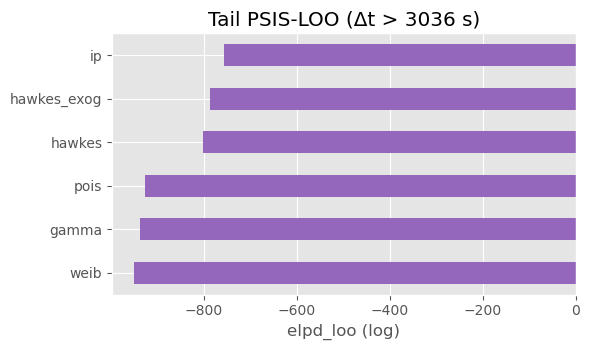

In [86]:
ax = cmp_tail_3036.sort_values("elpd_loo")["elpd_loo"].plot.barh(figsize=(6,3.6), color="tab:purple")
ax.set_title(f"Tail PSIS-LOO (Δt > {int(tau3036)} s)"); ax.set_xlabel("elpd_loo (log)")
plt.tight_layout();plt.savefig(OUT/"tailPSISI3036.png", dpi=160); plt.show()

In [87]:
# dt: 1D array of positive inter-arrival times
# coords = {"interval": np.arange(len(dt))}

with pm.Model(coords=coords) as pois_m:
    dt_c = pm.Data("dt", np.asarray(dt), dims="interval")

    # Prior on exponential rate
    mu = pm.HalfNormal("mu", sigma=1.0)

    # Observed likelihood: dt_i ~ Exponential(rate=mu)
    y = pm.Exponential("y", lam=mu, observed=dt_c, dims="interval")

    # Sample posterior, storing pointwise log-likelihood
    id_pois = pm.sample(
        draws=1200,
        tune=1200,
        chains=4,
        target_accept=0.9,
        init="adapt_diag",
        random_seed=42,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True},
    )

    # Sample posterior predictive and attach to idata
    id_pois = pm.sample_posterior_predictive(
        id_pois,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=42,
    )

# LOO-PIT
loo_pit_pois = az.loo_pit(id_pois, y="y")

# Basic summary
print(loo_pit_pois)

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_200 tune and 1_200 draw iterations (4_800 + 4_800 draws total) took 9 seconds.
Sampling: [y]


Output()

[0.         0.59562616 0.68854956 ... 0.33125466 0.50585705 0.22834341]


In [88]:
#az.plot_loo_pit(id_pois, y="y", ecdf=True)
#plt.show()

In [89]:
"""plt.figure(figsize=(7, 4))
plt.hist(np.asarray(loo_pit_pois), bins=20, edgecolor="black")
plt.axhline(len(np.asarray(loo_pit_pois)) / 20, linestyle="--")
plt.xlabel("LOO-PIT")
plt.ylabel("Count")
plt.title("Poisson/Exponential model: LOO-PIT histogram")
plt.show()"""

'plt.figure(figsize=(7, 4))\nplt.hist(np.asarray(loo_pit_pois), bins=20, edgecolor="black")\nplt.axhline(len(np.asarray(loo_pit_pois)) / 20, linestyle="--")\nplt.xlabel("LOO-PIT")\nplt.ylabel("Count")\nplt.title("Poisson/Exponential model: LOO-PIT histogram")\nplt.show()'

In [90]:
"""u = np.sort(np.asarray(loo_pit_pois))
n = len(u)
ecdf = np.arange(1, n + 1) / n

plt.figure(figsize=(5, 5))
plt.plot(u, ecdf, label="Empirical LOO-PIT ECDF")
plt.plot([0, 1], [0, 1], "--", label="Uniform(0,1)")
plt.xlabel("u")
plt.ylabel("F(u)")
plt.title("Poisson/Exponential model: LOO-PIT ECDF")
plt.legend()
plt.show()"""

'u = np.sort(np.asarray(loo_pit_pois))\nn = len(u)\necdf = np.arange(1, n + 1) / n\n\nplt.figure(figsize=(5, 5))\nplt.plot(u, ecdf, label="Empirical LOO-PIT ECDF")\nplt.plot([0, 1], [0, 1], "--", label="Uniform(0,1)")\nplt.xlabel("u")\nplt.ylabel("F(u)")\nplt.title("Poisson/Exponential model: LOO-PIT ECDF")\nplt.legend()\nplt.show()'

In [91]:
az.to_netcdf(id_pois, "models/poisson_model_normal.nc")

'models/poisson_model_normal.nc'

In [92]:
weib_m = build_weibull_model(dt, coords)

with weib_m:
    id_weib = pm.sample_posterior_predictive(
        id_weib,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=42,
    )

loo_weib = az.loo(id_weib, pointwise=True)
loo_pit_weib = az.loo_pit(id_weib, y="y")

Sampling: [y]


Output()

In [ ]:
gam_m  = build_gamma_model(dt,coords)

with gam_m:
    id_gamma = pm.sample_posterior_predictive(
        id_gamma,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=42,
    )

# LOO-PIT
loo_pit_gamma = az.loo_pit(id_gamma, y="y")

print(loo_pit_gamma)

Sampling: [y]


Output()

In [77]:
"""coords = {"interval": np.arange(len(dt))}

with pm.Model(coords=coords) as hawkes_m:
    dt_c = pm.Data("dt", np.asarray(dt, dtype=float), dims="interval")
    dt_template = pm.Data("dt_template", np.asarray(dt, dtype=float), dims="interval")

    mu = pm.HalfNormal("mu", 1.0)
    beta = pm.HalfNormal("beta", 1.0)
    rho = pm.Beta("rho", 2, 5)
    alpha = pm.Deterministic("alpha", rho * beta)

    ll_i = hawkes_ll_interval_pt(dt_c, mu, alpha, beta)
    pm.Deterministic("ll_interval", ll_i, dims="interval")

    def hawkes_logp(value, dt_template, mu, alpha, beta):
        return pt.sum(hawkes_ll_interval_pt(value, mu, alpha, beta))

    y = pm.CustomDist(
        "y",
        dt_template,
        mu,
        alpha,
        beta,
        logp=hawkes_logp,
        random=hawkes_random,
        observed=dt_c,
        dims="interval",
        signature="(n),(),(),()->(n)",
    )

    id_hawkes = pm.sample(
        1200,
        tune=1200,
        chains=4,
        step=pm.Metropolis(),
        return_inferencedata=True,
        init="adapt_diag",
        random_seed=42,
    )

id_hawkes.add_groups({"log_likelihood": {"y": id_hawkes.posterior["ll_interval"]}})"""

'coords = {"interval": np.arange(len(dt))}\n\nwith pm.Model(coords=coords) as hawkes_m:\n    dt_c = pm.Data("dt", np.asarray(dt, dtype=float), dims="interval")\n    dt_template = pm.Data("dt_template", np.asarray(dt, dtype=float), dims="interval")\n\n    mu = pm.HalfNormal("mu", 1.0)\n    beta = pm.HalfNormal("beta", 1.0)\n    rho = pm.Beta("rho", 2, 5)\n    alpha = pm.Deterministic("alpha", rho * beta)\n\n    ll_i = hawkes_ll_interval_pt(dt_c, mu, alpha, beta)\n    pm.Deterministic("ll_interval", ll_i, dims="interval")\n\n    def hawkes_logp(value, dt_template, mu, alpha, beta):\n        return pt.sum(hawkes_ll_interval_pt(value, mu, alpha, beta))\n\n    y = pm.CustomDist(\n        "y",\n        dt_template,\n        mu,\n        alpha,\n        beta,\n        logp=hawkes_logp,\n        random=hawkes_random,\n        observed=dt_c,\n        dims="interval",\n        signature="(n),(),(),()->(n)",\n    )\n\n    id_hawkes = pm.sample(\n        1200,\n        tune=1200,\n        chains=4

In [78]:
"""with hawkes_m:
    id_hawkes = pm.sample_posterior_predictive(
        id_hawkes,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=42,
    )

loo_hawkes = az.loo(id_hawkes, pointwise=True, var_name="y")
loo_pit_hawkes = az.loo_pit(id_hawkes, y="y")"""

'with hawkes_m:\n    id_hawkes = pm.sample_posterior_predictive(\n        id_hawkes,\n        var_names=["y"],\n        extend_inferencedata=True,\n        random_seed=42,\n    )\n\nloo_hawkes = az.loo(id_hawkes, pointwise=True, var_name="y")\nloo_pit_hawkes = az.loo_pit(id_hawkes, y="y")'

In [79]:
#az.to_netcdf(id_hawkes, "models/hawkes_model_generative.nc")

In [73]:
id_hawkes=az.from_netcdf("models/hawkes_model_generative.nc") 

In [76]:
loo_hawkes = az.loo(id_hawkes, pointwise=True, var_name="y")
loo_pit_hawkes = az.loo_pit(id_hawkes, y="y")

In [77]:
az.summary(loo_pit_hawkes)

arviz - WARNING - Shape validation failed: input_shape: (1, 15000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x,0.504,0.286,0.032,0.961,0.002,0.001,15013.0,14567.0,NaN


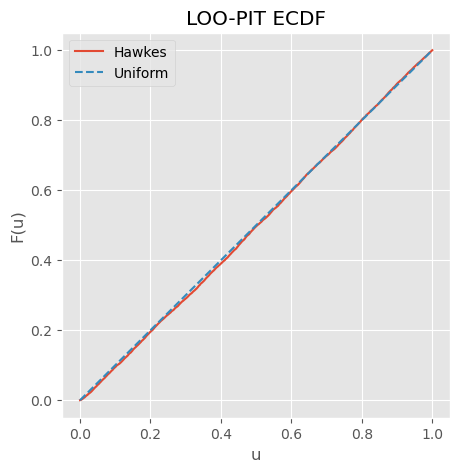

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def plot_loo_pit_ecdf(u, label):
    u = np.sort(u)
    n = len(u)
    ecdf = np.arange(1, n+1)/n
    plt.plot(u, ecdf, label=label)

plt.figure(figsize=(5,5))
plot_loo_pit_ecdf(np.asarray(loo_pit_hawkes), "Hawkes")

plt.plot([0,1],[0,1],"--", label="Uniform")
plt.xlabel("u")
plt.ylabel("F(u)")
plt.title("LOO-PIT ECDF")
plt.legend()
plt.show()

In [84]:
N, p = X.shape

with pm.Model(coords={"interval": np.arange(N), "feat": np.arange(p)}) as ip_m:
    dt_c = pm.Data("dt", np.asarray(dt, dtype=float), dims="interval")
    X_c  = pm.Data("X",  np.asarray(X, dtype=float), dims=("interval", "feat"))

    beta0 = pm.Normal("beta0", 0.0, 1.0)
    b     = pm.Normal("b", 0.0, 1.0, dims="feat")

    lin = pm.math.clip(beta0 + pm.math.dot(X_c, b), -40, 40)
    lam = pm.Deterministic("lam", pm.math.exp(lin), dims="interval")

    # Generative likelihood
    y = pm.Exponential("y", lam=lam, observed=dt_c, dims="interval")

    id_ip = pm.sample(
        1200,
        tune=1200,
        chains=4,
        target_accept=0.9,
        return_inferencedata=True,
        init="adapt_diag",
        idata_kwargs={"log_likelihood": True},
        random_seed=42,
    )

    id_ip = pm.sample_posterior_predictive(
        id_ip,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=42,
    )

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, b]


Output()

Sampling 4 chains for 1_200 tune and 1_200 draw iterations (4_800 + 4_800 draws total) took 31 seconds.
Sampling: [y]


Output()

In [85]:
loo_ip = az.loo(id_ip, pointwise=True, var_name="y")
print(loo_ip)

/home/phumz/miniconda3/envs/bayes310/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4800 posterior samples and 15000 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -108515.01   129.20
p_loo       17.37        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     14999  100.0%
   (0.70, 1]   (bad)          1    0.0%
   (1, Inf)   (very bad)     0    0.0%



In [86]:
loo_pit_ip = az.loo_pit(id_ip, y="y")
print(loo_pit_ip)

[0.         0.78610745 0.87136045 ... 0.46996619 0.68563935 0.36190052]


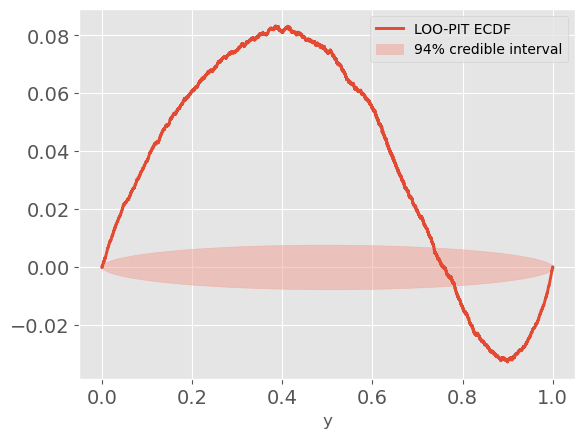

In [87]:
az.plot_loo_pit(id_ip, y="y", ecdf=True)
plt.show()

In [88]:
#az.to_netcdf(id_ip, "models/ip_model_generative.nc")

In [89]:
u = np.sort(np.asarray(loo_pit_ip))
n = len(u)
ecdf = np.arange(1, n + 1) / n
ks_ip = np.max(np.abs(ecdf - u))
print("LOO-PIT KS distance:", ks_ip)

LOO-PIT KS distance: 0.08310941572539443


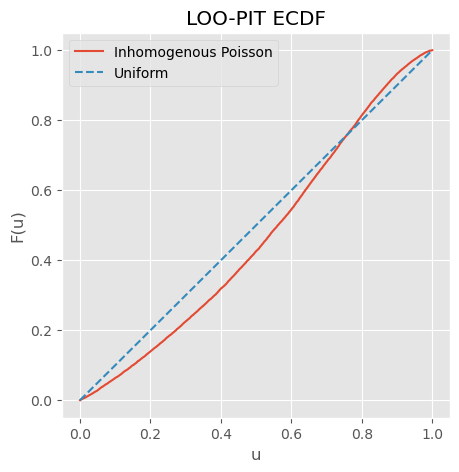

In [90]:
def plot_loo_pit_ecdf(u, label):
    u = np.sort(u)
    n = len(u)
    ecdf = np.arange(1, n+1)/n
    plt.plot(u, ecdf, label=label)

plt.figure(figsize=(5,5))
plot_loo_pit_ecdf(np.asarray(loo_pit_ip), "Inhomogenous Poisson")

plt.plot([0,1],[0,1],"--", label="Uniform")
plt.xlabel("u")
plt.ylabel("F(u)")
plt.title("LOO-PIT ECDF")
plt.legend()
plt.show()

In [91]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

In [92]:
"""loo_pit_hexog, k_hexog = loo_pit_hawkes_covariates(
    id_hawkes_exog, dt, X, X_mean, X_std
)"""

loo_pit_hexog, k_hexog = loo_pit_hawkes_covariates_chunked(
    id_hawkes_exog, dt, X, X_mean, X_std
)

Processed interval 0/15000
Processed interval 2000/15000
Processed interval 4000/15000
Processed interval 6000/15000
Processed interval 8000/15000
Processed interval 10000/15000
Processed interval 12000/15000
Processed interval 14000/15000


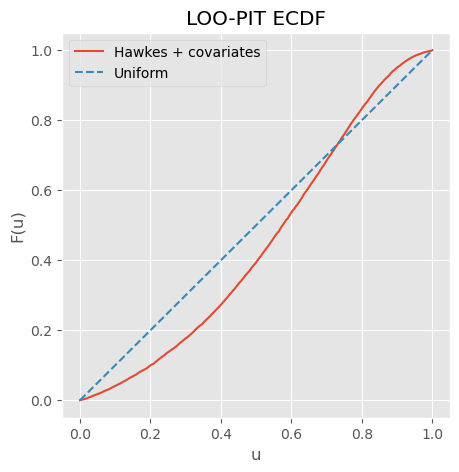

In [93]:
import matplotlib.pyplot as plt

u = np.sort(loo_pit_hexog)
n = len(u)
ecdf = np.arange(1, n + 1) / n

plt.figure(figsize=(5, 5))
plt.plot(u, ecdf, label="Hawkes + covariates")
plt.plot([0, 1], [0, 1], "--", label="Uniform")
plt.xlabel("u")
plt.ylabel("F(u)")
plt.title("LOO-PIT ECDF")
plt.legend()
plt.show()

In [73]:
plt.figure(figsize=(6,6))

def plot_ecdf(u, label):
    u = np.sort(np.asarray(u))
    n = len(u)
    ecdf = np.arange(1, n+1)/n
    plt.plot(u, ecdf, label=label)

plot_ecdf(loo_pit_pois, "Poisson")
plot_ecdf(loo_pit_gamma, "Gamma")
plot_ecdf(loo_pit_weib, "Weibull")
plot_ecdf(loo_pit_ip, "IP")
plot_ecdf(loo_pit_hawkes, "Hawkes")
plot_ecdf(loo_pit_hexog, "Hawkes + covariates")


plt.plot([0,1],[0,1],'--', color='black', label="Uniform")
plt.legend()
plt.title("LOO-PIT calibration comparison")
plt.xlabel("u")
plt.ylabel("F(u)")
plt.savefig(OUT/"loo_pit.png", dpi=160)
plt.show()

NameError: name 'loo_pit_pois' is not defined

<Figure size 600x600 with 0 Axes>

In [95]:
taus

array([   0.,   30.,   60.,   90.,  120.,  150.,  180.,  210.,  240.,
        270.,  300.,  330.,  360.,  390.,  420.,  450.,  480.,  510.,
        540.,  570.,  600.,  630.,  660.,  690.,  720.,  750.,  780.,
        810.,  840.,  870.,  900.,  930.,  960.,  990., 1020., 1050.,
       1080., 1110., 1140., 1170., 1200., 1230., 1260., 1290., 1320.,
       1350., 1380., 1410., 1440., 1470., 1500., 1530., 1560., 1590.,
       1620., 1650., 1680., 1710., 1740., 1770., 1800., 1830., 1860.,
       1890., 1920., 1950., 1980., 2010., 2040., 2070., 2100., 2130.,
       2160., 2190., 2220., 2250., 2280., 2310., 2340., 2370., 2400.,
       2430., 2460., 2490., 2520., 2550., 2580., 2610., 2640., 2670.,
       2700., 2730., 2760., 2790., 2820., 2850., 2880., 2910., 2940.,
       2970., 3000., 3030., 3060., 3090., 3120., 3150., 3180., 3210.,
       3240., 3270., 3300., 3330., 3360., 3390., 3420., 3450., 3480.,
       3510., 3540., 3570., 3600.])

In [63]:
#rho =functions._draws(id_hawkes_exog, "rho") 
lambda_draws = functions._draws(id_pois,"mu")


intercept_ip = functions._draws(id_ip, "beta0")
beta_ip = functions._draws(id_ip, "b")

k_weibull = functions._draws(id_weib, "k")
lambda_weibull =functions._draws(id_weib, "lambda")

a_gamma = functions._draws(id_gamma, "alpha")
theta_gamma = functions._draws(id_gamma, "beta")

#mu_hat = functions._draws(id_hawkes, "mu")
#alpha_hat =functions._draws(id_hawkes, "alpha")
#beta_hat = functions._draws(id_hawkes, "beta")
#rho_hat = functions._draws(id_hawkes, "rho")

In [41]:
beta_ip.shape

(4800, 7)

In [81]:
results = []

taus = np.arange(0, 6001, 30, dtype=int)
tail_thresholds = (600, 1800, 2640, 3036)

In [82]:
poisson_summary, poisson_pointwise = score_poisson_model(
    dt=dt,
    lambda_draws=lambda_draws,
    taus=taus,
    tail_thresholds=tail_thresholds,
)

results.append(poisson_summary)


In [83]:
ip_summary, ip_pointwise = score_ip_covariates_model(
    dt=dt,
    X=X,
    intercept=intercept_ip,
    beta=beta_ip,
    taus=taus,
    tail_thresholds=tail_thresholds,
)

results.append(ip_summary)

In [84]:
weibull_summary, weibull_pointwise = score_weibull_model(
    dt=dt,
    shape_k=k_weibull,
    scale_lambda=lambda_weibull,
    taus=taus,
    tail_thresholds=tail_thresholds,
)

results.append(weibull_summary)


In [85]:
gamma_summary, gamma_pointwise = score_gamma_model(
    dt=dt,
    shape_draws=a_gamma,
    scale_draws=theta_gamma,
    taus=taus,
    tail_thresholds=tail_thresholds,
)

results.append(gamma_summary)

In [86]:
print("first 10 event_times:", times[:10])
print("is nondecreasing:", np.all(np.diff(times) >= 0))

first 10 event_times: [   0.  545. 1257. 2159. 2890. 3829. 3963. 5183. 5676. 5863.]
is nondecreasing: True


In [87]:
times_seconds

array([0.000000e+00, 5.450000e+02, 1.257000e+03, ..., 8.742221e+06,
       8.742624e+06, 8.742777e+06])

In [88]:
t0=time.time()
hawkes_summary, hawkes_pointwise = score_hawkes_model(
    dt=dt,
    event_times=times_seconds,
    id_hawkes=id_hawkes,
    taus=taus,
    tail_thresholds=tail_thresholds,
)

results.append(hawkes_summary)

runtime_s=time.time()-t0
runtime_s

12065.43410396576

In [89]:
t0=time.time()
hawkes_cov_summary, hawkes_cov_pointwise = score_hawkes_covariates_model(
    dt=dt,
    X=X,
    event_times=times_seconds,
    id_hawkes_exog=id_hawkes_exog,
    taus=taus,
    tail_thresholds=tail_thresholds,
)

results.append(hawkes_cov_summary)

runtime_s=time.time()-t0
runtime_s

11237.582710027695

In [119]:
results_clean = [
    r[0] if isinstance(r, tuple) else r
    for r in results
]

comparison_df = (
    pd.DataFrame(results_clean)
    .sort_values("CRPS")
    .reset_index(drop=True)
)

comparison_df

,model,CRPS,twCRPS>600,twCRPS>1800,twCRPS>2640,twCRPS>3036,BS(Y>600),BS(Y>1800),BS(Y>2640),BS(Y>3036)
0,Hawkes + covariates,230.909179,147.483409,27.651226,7.740833,4.174685,0.166292,0.039992,0.011038,0.005993
1,IP + covariates,264.875303,168.580402,45.263371,22.606280,16.933681,0.182673,0.041328,0.015797,0.011208
2,Hawkes,286.956129,171.057983,24.748400,5.683883,2.631010,0.229413,0.040073,0.009641,0.004910
3,Poisson,286.959083,171.053691,24.746209,5.683466,2.630873,0.229418,0.040067,0.009640,0.004909
4,Weibull,567.468000,209.962000,25.304000,5.714000,2.638000,0.356533,0.041800,0.009733,0.004933
5,Gamma,567.468000,209.962000,25.304000,5.714000,2.638000,0.356533,0.041800,0.009733,0.004933


In [124]:
bootstrap_results = []

comparisons = [
    # ============================================================
    # CRPS
    # Best: Hawkes + covariates
    # Second-best: IP + covariates
    # ============================================================
    (
        "CRPS",
        None,
        "Hawkes + covariates",
        hawkes_cov_pointwise["CRPS"],
        "IP + covariates",
        ip_pointwise["CRPS"],
    ),

    # ============================================================
    # twCRPS > 600 seconds
    # Best: Hawkes + covariates
    # Second-best: IP + covariates
    # ============================================================
    (
        "twCRPS",
        600,
        "Hawkes + covariates",
        hawkes_cov_pointwise["twCRPS"][600],
        "IP + covariates",
        ip_pointwise["twCRPS"][600],
    ),

    # ============================================================
    # twCRPS > 1800 seconds
    # Best: Hawkes
    # Second-best: Poisson
    # ============================================================
    (
        "twCRPS",
        1800,
        "Hawkes",
        hawkes_pointwise["twCRPS"][1800],
        "Poisson",
        poisson_pointwise["twCRPS"][1800],
    ),

    # ============================================================
    # twCRPS > 2640 seconds
    # Best: Poisson
    # Second-best: Hawkes
    # ============================================================
    (
        "twCRPS",
        2640,
        "Poisson",
        poisson_pointwise["twCRPS"][2640],
        "Hawkes",
        hawkes_pointwise["twCRPS"][2640],
    ),

    # ============================================================
    # twCRPS > 3036 seconds
    # Best: Hawkes
    # Second-best: Weibull
    # ============================================================
    (
        "twCRPS",
        3036,
        "Hawkes",
        hawkes_pointwise["twCRPS"][3036],
        "Weibull",
        weibull_pointwise["twCRPS"][3036],
    ),

    # ============================================================
    # Brier > 600 seconds
    # Best: Hawkes + covariates
    # Second-best: IP + covariates
    # ============================================================
    (
        "Brier",
        600,
        "Hawkes + covariates",
        hawkes_cov_pointwise["Brier"][600],
        "IP + covariates",
        ip_pointwise["Brier"][600],
    ),

    # ============================================================
    # Brier > 1800 seconds
    # Best: Hawkes + covariates
    # Second-best: Poisson
    # ============================================================
    (
        "Brier",
        1800,
        "Hawkes + covariates",
        hawkes_cov_pointwise["Brier"][1800],
        "Poisson",
        poisson_pointwise["Brier"][1800],
    ),

    # ============================================================
    # Brier > 2640 seconds
    # Best: Poisson
    # Second-best: Hawkes
    # ============================================================
    (
        "Brier",
        2640,
        "Poisson",
        poisson_pointwise["Brier"][2640],
         "Weibull",
        weibull_pointwise["Brier"][2640],
    ),

    # ============================================================
    # Brier > 3036 seconds
    # Best: Hawkes
    # Second-best: Weibull
    # ============================================================
    (
        "Brier",
        3036,
       "Poisson", 
        poisson_pointwise["Brier"][3036],
        "Weibull",
        weibull_pointwise["Brier"][3036],
    ),
]


for metric, threshold, name_a, score_a, name_b, score_b in comparisons:

    res = paired_block_bootstrap_ci(
        score_a,
        score_b,
        block_length=50,
        n_boot=5000,
        ci=0.95,
        random_seed=42,
    )

    bootstrap_results.append({
        "metric": (
            metric
            if threshold is None
            else f"{metric}>{threshold}"
        ),
        "model_A": name_a,
        "model_B": name_b,
        "score_A": res["score_A"],
        "score_B": res["score_B"],
        "difference_A_minus_B": res["difference_A_minus_B"],
        "bootstrap_SE": res["bootstrap_SE"],
        "CI_lower": res["CI_lower"],
        "CI_upper": res["CI_upper"],
        "clear_difference": (
            res["CI_upper"] < 0
            or res["CI_lower"] > 0
        ),
    })


bootstrap_df = pd.DataFrame(bootstrap_results)

bootstrap_df

,metric,model_A,model_B,score_A,score_B,difference_A_minus_B,bootstrap_SE,CI_lower,CI_upper,clear_difference
0,CRPS,Hawkes + covariates,IP + covariates,230.909179,264.875303,-33.966125,4.528721,-44.897797,-27.137922,True
1,twCRPS>600,Hawkes + covariates,IP + covariates,147.483409,168.580402,-21.096992,4.412327,-31.914367,-14.463591,True
2,twCRPS>1800,Hawkes,Poisson,24.748400,24.746209,0.002191,0.001065,-0.000242,0.003918,False
3,twCRPS>2640,Poisson,Hawkes,5.683466,5.683883,-0.000417,0.000180,-0.000729,-0.000018,True
4,twCRPS>3036,Hawkes,Weibull,2.631010,2.638000,-0.006990,0.002023,-0.011128,-0.003163,True
5,Brier>600,Hawkes + covariates,IP + covariates,0.166292,0.182673,-0.016381,0.001724,-0.019707,-0.012961,True
6,Brier>1800,Hawkes + covariates,Poisson,0.039992,0.040067,-0.000075,0.000665,-0.001643,0.000956,False
7,Brier>2640,Poisson,Weibull,0.009640,0.009733,-0.000094,0.000017,-0.000130,-0.000060,True
8,Brier>3036,Poisson,Weibull,0.004909,0.004933,-0.000024,0.000006,-0.000036,-0.000012,True


In [121]:
beta_h = functions._draws(id_hawkes, "beta")
rho_h  = functions._draws(id_hawkes, "rho")

print("hawkes beta min/max:", np.nanmin(beta_h), np.nanmax(beta_h))
print("hawkes rho  min/max:", np.nanmin(rho_h), np.nanmax(rho_h))
print("hawkes beta <= 0:", np.sum(beta_h <= 0))
print("hawkes beta near 0:", np.sum(np.abs(beta_h) < 1e-10))

hawkes beta min/max: 1.2691166318934275e-09 1.8660850826637732
hawkes rho  min/max: 2.429303993552662e-05 0.40162554542719403
hawkes beta <= 0: 0
hawkes beta near 0: 0


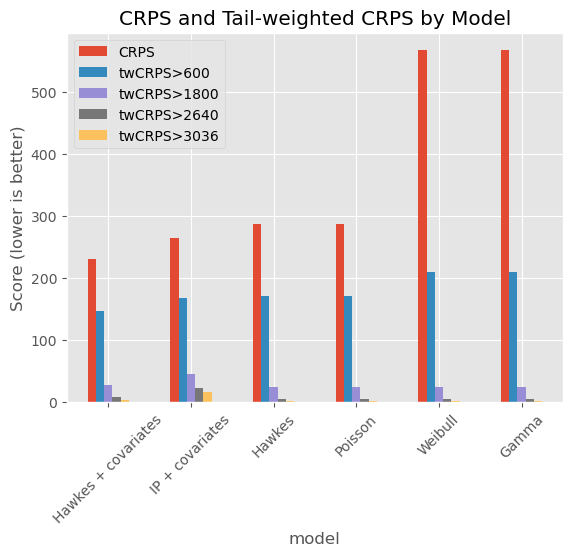

In [122]:
df = comparison_df.set_index("model")

df[["CRPS", "twCRPS>600", "twCRPS>1800", "twCRPS>2640","twCRPS>3036"]].plot(kind="bar")
plt.ylabel("Score (lower is better)")
plt.title("CRPS and Tail-weighted CRPS by Model")
plt.xticks(rotation=45)
plt.tight_layout
plt.savefig(OUT/"brier_tail.png", dpi=160)
plt.show()

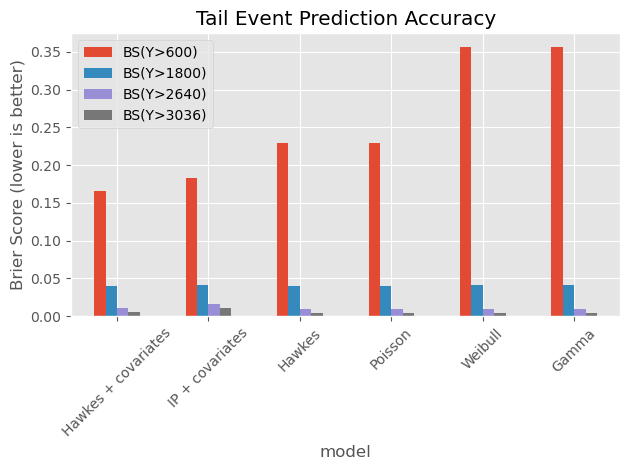

In [123]:
df[["BS(Y>600)", "BS(Y>1800)", "BS(Y>2640)","BS(Y>3036)"]].plot(kind="bar")
plt.ylabel("Brier Score (lower is better)")
plt.title("Tail Event Prediction Accuracy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT/"brier_tail.png", dpi=160)
plt.show()

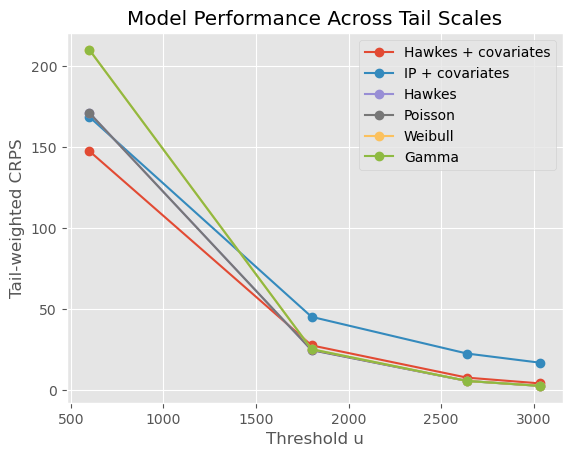

In [96]:
thresholds = np.array([600, 1800, 2640,3036])

for model in comparison_df["model"]:
    row = comparison_df[comparison_df["model"] == model].iloc[0]
    tw = [row[f"twCRPS>{u}"] for u in thresholds]
    plt.plot(thresholds, tw, marker="o", label=model)

plt.xlabel("Threshold u")
plt.ylabel("Tail-weighted CRPS")
plt.title("Model Performance Across Tail Scales")
plt.legend()
plt.savefig(OUT/"twcrps_tail.png", dpi=160)
plt.show()

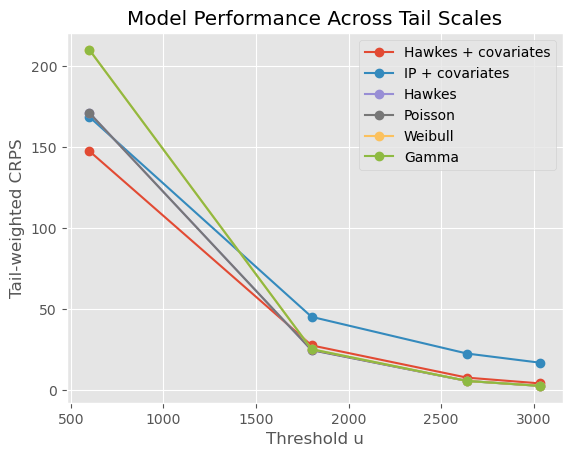

In [97]:
thresholds = np.array([600, 1800, 2640, 3036])

for model in comparison_df["model"]:
    row = comparison_df[comparison_df["model"] == model].iloc[0]
    tw = [row[f"twCRPS>{u}"] for u in thresholds]
    plt.plot(thresholds, tw, marker="o", label=model)

plt.xlabel("Threshold u")
plt.ylabel("Tail-weighted CRPS")
plt.title("Model Performance Across Tail Scales")
plt.legend()
plt.savefig(OUT/"twcrps_tail_2.png", dpi=160)
plt.show()

In [98]:
ROLL_DRAWS = 600
ROLL_TUNE = 600
ROLL_CHAINS = 2
ROLL_TARGET_ACCEPT = 0.95
THRESHOLDS = [600, 1800, 2640,3036]

In [34]:
rolling_windows = [
    {
        "name": "W1",
        "train_start": 0,
        "train_end": 6000,
        "test_start": 6000,
        "test_end": 9000,
    },
    {
        "name": "W2",
        "train_start": 3000,
        "train_end": 9000,
        "test_start": 9000,
        "test_end": 12000,
    },
    {
        "name": "W3",
        "train_start": 6000,
        "train_end": 12000,
        "test_start": 12000,
        "test_end": 15000,
    },
]

In [61]:
all_results = []

for w in rolling_windows:

    print("\n" + "=" * 80)
    print(f"ROLLING WINDOW {w['name']}")
    print("=" * 80)

    tr = slice(
        w["train_start"],
        w["train_end"]
    )

    te = slice(
        w["test_start"],
        w["test_end"]
    )

    dt_train = dt[tr]
    X_train = X[tr]

    dt_test = dt[te]
    X_test = X[te]

    # -------------------------------------------------------
    # FIT IP + COVARIATES
    # -------------------------------------------------------

    (
        ip_model,
        ip_idata,
        ip_mean,
        ip_std
    ) = fit_ip_covariates(
        dt_train,
        X_train,
        feature_names=feat_names,
        draws=600,
        tune=600,
        chains=2,
        target_accept=0.95,
        random_seed=42,
    )

    # -------------------------------------------------------
    # FIT HAWKES + COVARIATES
    # -------------------------------------------------------

    (
        hawkes_model,
        hawkes_idata,
        hawkes_mean,
        hawkes_std
    ) = fit_hawkes_covariates(
        dt_train,
        X_train,
        feature_names=feat_names,
        draws=600,
        tune=600,
        chains=2,
        target_accept=0.95,
        random_seed=42,
    )

    # -------------------------------------------------------
    # SAVE IMMEDIATELY
    # -------------------------------------------------------

    ip_idata.to_netcdf(
        f"rolling_{w['name']}_ip.nc"
    )

    hawkes_idata.to_netcdf(
        f"rolling_{w['name']}_hawkes.nc"
    )

    # -------------------------------------------------------
    # FUTURE-WINDOW SCORES
    # -------------------------------------------------------

    lpd_ip = score_ip_future(
        ip_idata,
        dt_test,
        X_test,
        ip_mean,
        ip_std,
    )

    lpd_hawkes = score_hawkes_future(
        hawkes_idata,
        dt_train,
        dt_test,
        X_test,
        hawkes_mean,
        hawkes_std,
    )

    rows = summarize_future_scores(
        dt_test,
        lpd_ip,
        lpd_hawkes,
    )

    for row in rows:
        row["window"] = w["name"]

    all_results.extend(rows)


rolling_results = pd.DataFrame(
    all_results
)

rolling_results


ROLLING WINDOW W1


Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta0, b]


Output()

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_x, rho, decay]


Output()

...

Output()

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_x, rho, decay]


Output()

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 5302 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,region,n,IP_covariates,Hawkes_covariates,difference_Hawkes_minus_IP,winner,window
0,Full,3000,-21718.575341,-21546.889533,171.685808,Hawkes + covariates,W1
1,>600s,1056,-8715.296511,-8681.433169,33.863341,Hawkes + covariates,W1
2,>1800s,122,-1152.625307,-1162.533734,-9.908427,IP + covariates,W1
3,>2640s,39,-385.108950,-399.717434,-14.608484,IP + covariates,W1
4,Full,3000,-21916.678632,-21402.965062,513.713571,Hawkes + covariates,W2
5,>600s,1102,-9106.612911,-9006.810778,99.802133,Hawkes + covariates,W2
6,>1800s,136,-1286.774038,-1266.606491,20.167547,Hawkes + covariates,W2
7,>2640s,28,-276.324041,-283.414787,-7.090746,IP + covariates,W2
8,Full,3000,-22519.521875,-22259.415485,260.106390,Hawkes + covariates,W3
9,>600s,1107,-10085.546004,-9531.330785,554.215219,Hawkes + covariates,W3


In [62]:
rolling_results

,region,n,IP_covariates,Hawkes_covariates,difference_Hawkes_minus_IP,winner,window
0,Full,3000,-21718.575341,-21546.889533,171.685808,Hawkes + covariates,W1
1,>600s,1056,-8715.296511,-8681.433169,33.863341,Hawkes + covariates,W1
2,>1800s,122,-1152.625307,-1162.533734,-9.908427,IP + covariates,W1
3,>2640s,39,-385.108950,-399.717434,-14.608484,IP + covariates,W1
4,Full,3000,-21916.678632,-21402.965062,513.713571,Hawkes + covariates,W2
5,>600s,1102,-9106.612911,-9006.810778,99.802133,Hawkes + covariates,W2
6,>1800s,136,-1286.774038,-1266.606491,20.167547,Hawkes + covariates,W2
7,>2640s,28,-276.324041,-283.414787,-7.090746,IP + covariates,W2
8,Full,3000,-22519.521875,-22259.415485,260.106390,Hawkes + covariates,W3
9,>600s,1107,-10085.546004,-9531.330785,554.215219,Hawkes + covariates,W3


In [63]:
for w in rolling_windows:
    name = w["name"]

    idata_h = az.from_netcdf(
        f"rolling_{name}_hawkes.nc"
    )

    print("\n", name)

    print(
        az.summary(
            idata_h,
            var_names=["rho", "decay"],
            hdi_prob=0.94
        )
    )

    print(
        "divergences:",
        int(idata_h.sample_stats["diverging"].sum())
    )


 W1
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
rho    0.545  0.016   0.517    0.576      0.001      0.0     703.0     812.0   
decay  0.000  0.000   0.000    0.000      0.000      0.0    1089.0     762.0   

       r_hat  
rho      1.0  
decay    1.0  
divergences: 0

 W2
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
rho    0.537  0.017   0.504    0.568      0.001      0.0     672.0     754.0   
decay  0.000  0.000   0.000    0.000      0.000      0.0    1357.0     897.0   

       r_hat  
rho     1.00  
decay   1.01  
divergences: 0

 W3
       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
rho    0.56  0.017   0.527     0.59      0.001      0.0     702.0     761.0   
decay  0.00  0.000   0.000     0.00      0.000      0.0     972.0     814.0   

       r_hat  
rho      1.0  
decay    1.0  
divergences: 0


In [35]:
all_results_unc = []

for w in rolling_windows:

    name = w["name"]

    tr = slice(
        w["train_start"],
        w["train_end"]
    )

    te = slice(
        w["test_start"],
        w["test_end"]
    )

    dt_train = dt[tr]
    X_train = X[tr]

    dt_test = dt[te]
    X_test = X[te]

    # -------------------------------------------------------
    # LOAD SAVED IP FIT
    # -------------------------------------------------------

    ip_idata = az.from_netcdf(
        f"rolling_{name}_ip.nc"
    )

    # Recompute training-window scaling
    ip_mean = X_train.mean(axis=0)
    ip_std = X_train.std(axis=0, ddof=0)
    ip_std = np.where(ip_std == 0.0, 1.0, ip_std)

    # -------------------------------------------------------
    # LOAD SAVED HAWKES FIT
    # -------------------------------------------------------

    hawkes_idata = az.from_netcdf(
        f"rolling_{name}_hawkes.nc"
    )

    hawkes_mean = X_train.mean(axis=0)
    hawkes_std = X_train.std(axis=0, ddof=0)
    hawkes_std = np.where(
        hawkes_std == 0.0,
        1.0,
        hawkes_std
    )

    # -------------------------------------------------------
    # SCORE FUTURE WINDOW
    # -------------------------------------------------------

    lpd_ip = score_ip_future(
        ip_idata,
        dt_test,
        X_test,
        ip_mean,
        ip_std,
    )

    lpd_hawkes = score_hawkes_future(
        hawkes_idata,
        dt_train,
        dt_test,
        X_test,
        hawkes_mean,
        hawkes_std,
    )

    rows = summarize_future_scores_with_uncertainty(
        dt_test,
        lpd_ip,
        lpd_hawkes,
    )

    for row in rows:
        row["window"] = name

    all_results_unc.extend(rows)


rolling_results_unc = pd.DataFrame(
    all_results_unc
)

rolling_results_unc

,region,n,IP_total_LPD,Hawkes_total_LPD,total_diff_H_minus_IP,IP_mean_LPD,Hawkes_mean_LPD,mean_diff_H_minus_IP,SE_mean_diff,SE_total_diff,z_like_ratio,winner,window
0,Full,3000,-21718.575341,-21546.889533,171.685808,-7.239525,-7.182297,0.057229,0.008068,24.204741,7.093065,Hawkes + covariates,W1
1,>600s,1056,-8715.296511,-8681.433169,33.863341,-8.253122,-8.221054,0.032068,0.015737,16.618647,2.037671,Hawkes + covariates,W1
2,>1800s,122,-1152.625307,-1162.533734,-9.908427,-9.447748,-9.528965,-0.081217,0.051821,6.322142,-1.567258,IP + covariates,W1
3,>2640s,39,-385.108950,-399.717434,-14.608484,-9.874588,-10.249165,-0.374577,0.114661,4.471796,-3.266805,IP + covariates,W1
4,Full,3000,-21916.678632,-21402.965062,513.713571,-7.305560,-7.134322,0.171238,0.008258,24.774354,20.735700,Hawkes + covariates,W2
5,>600s,1102,-9106.612911,-9006.810778,99.802133,-8.263714,-8.173150,0.090565,0.011663,12.852251,7.765343,Hawkes + covariates,W2
6,>1800s,136,-1286.774038,-1266.606491,20.167547,-9.461574,-9.313283,0.148291,0.049771,6.768808,2.979483,Hawkes + covariates,W2
7,>2640s,28,-276.324041,-283.414787,-7.090746,-9.868716,-10.121957,-0.253241,0.134793,3.774217,-1.878733,IP + covariates,W2
8,Full,3000,-22519.521875,-22259.415485,260.106390,-7.506507,-7.419805,0.086702,0.016035,48.104891,5.407067,Hawkes + covariates,W3
9,>600s,1107,-10085.546004,-9531.330785,554.215219,-9.110701,-8.610055,0.500646,0.033098,36.639395,15.126211,Hawkes + covariates,W3


In [40]:

all_results = []

for w in rolling_windows:

    print("\n" + "=" * 80)
    print(f"ROLLING WINDOW {w['name']}")
    print("=" * 80)

    tr = slice(
        w["train_start"],
        w["train_end"]
    )

    te = slice(
        w["test_start"],
        w["test_end"]
    )

    dt_train = dt[tr]
    X_train = X[tr]

    dt_test = dt[te]
    X_test = X[te]

    # -------------------------------------------------------
    # Training-window standardisation statistics
    # These reproduce the values used inside both fitting
    # functions.
    # -------------------------------------------------------

    train_mean = X_train.mean(axis=0)
    train_std = X_train.std(axis=0, ddof=0)
    train_std = np.where(train_std == 0.0, 1.0, train_std)

    ip_mean = train_mean
    ip_std = train_std

    hawkes_mean = train_mean
    hawkes_std = train_std

    # -------------------------------------------------------
    # FILE NAMES
    # -------------------------------------------------------

    ip_file = f"rolling_{w['name']}_ip.nc"
    hawkes_file = f"rolling_{w['name']}_hawkes.nc"

    # -------------------------------------------------------
    # IP + COVARIATES:
    # LOAD IF SAVED, OTHERWISE FIT AND SAVE
    # -------------------------------------------------------

    if os.path.exists(ip_file):

        print(f"Loading saved IP model: {ip_file}")

        ip_idata = az.from_netcdf(ip_file)

    else:

        print(f"Fitting IP model for {w['name']}...")

        (
            ip_model,
            ip_idata,
            ip_mean,
            ip_std
        ) = fit_ip_covariates(
            dt_train,
            X_train,
            feature_names=feat_names,
            draws=600,
            tune=600,
            chains=2,
            target_accept=0.95,
            random_seed=42,
        )

        ip_idata.to_netcdf(ip_file)

        print(f"Saved IP model: {ip_file}")

    # -------------------------------------------------------
    # HAWKES + COVARIATES:
    # LOAD IF SAVED, OTHERWISE FIT AND SAVE
    # -------------------------------------------------------

    if os.path.exists(hawkes_file):

        print(f"Loading saved Hawkes model: {hawkes_file}")

        hawkes_idata = az.from_netcdf(hawkes_file)

    else:

        print(f"Fitting Hawkes model for {w['name']}...")

        (
            hawkes_model,
            hawkes_idata,
            hawkes_mean,
            hawkes_std
        ) = fit_hawkes_covariates(
            dt_train,
            X_train,
            feature_names=feat_names,
            draws=600,
            tune=600,
            chains=2,
            target_accept=0.95,
            random_seed=42,
        )

        hawkes_idata.to_netcdf(hawkes_file)

        print(f"Saved Hawkes model: {hawkes_file}")

    # -------------------------------------------------------
    # FUTURE-WINDOW SCORES
    # No fitting occurs here.
    # -------------------------------------------------------

    lpd_ip = score_ip_future(
        ip_idata,
        dt_test,
        X_test,
        ip_mean,
        ip_std,
    )

    lpd_hawkes = score_hawkes_future(
        hawkes_idata,
        dt_train,
        dt_test,
        X_test,
        hawkes_mean,
        hawkes_std,
    )

    rows = summarize_future_scores(
        dt_test,
        lpd_ip,
        lpd_hawkes,
    )

    for row in rows:
        row["window"] = w["name"]

    all_results.extend(rows)


rolling_results = pd.DataFrame(all_results)

rolling_results


ROLLING WINDOW W1
Loading saved IP model: rolling_W1_ip.nc
Loading saved Hawkes model: rolling_W1_hawkes.nc

ROLLING WINDOW W2
Loading saved IP model: rolling_W2_ip.nc
Loading saved Hawkes model: rolling_W2_hawkes.nc

ROLLING WINDOW W3
Loading saved IP model: rolling_W3_ip.nc
Loading saved Hawkes model: rolling_W3_hawkes.nc


,region,n,IP_covariates,Hawkes_covariates,difference_Hawkes_minus_IP,winner,window
0,Full,3000,-21718.575341,-21546.889533,171.685808,Hawkes + covariates,W1
1,>600s,1056,-8715.296511,-8681.433169,33.863341,Hawkes + covariates,W1
2,>1800s,122,-1152.625307,-1162.533734,-9.908427,IP + covariates,W1
3,>2640s,39,-385.108950,-399.717434,-14.608484,IP + covariates,W1
4,>3036s,19,-194.595945,-205.437649,-10.841703,IP + covariates,W1
5,Full,3000,-21916.678632,-21402.965062,513.713571,Hawkes + covariates,W2
6,>600s,1102,-9106.612911,-9006.810778,99.802133,Hawkes + covariates,W2
7,>1800s,136,-1286.774038,-1266.606491,20.167547,Hawkes + covariates,W2
8,>2640s,28,-276.324041,-283.414787,-7.090746,IP + covariates,W2
9,>3036s,16,-157.927417,-166.332706,-8.405289,IP + covariates,W2


In [80]:
[(name, type(value).__name__)
 for name, value in globals().items()
 if isinstance(value, az.InferenceData)]

[('id_pois', 'InferenceData'),
 ('id_gamma', 'InferenceData'),
 ('id_weib', 'InferenceData'),
 ('id_ip', 'InferenceData'),
 ('id_hawkes', 'InferenceData'),
 ('id_hawkes_exog', 'InferenceData'),
 ('id_hawkes_stationary', 'InferenceData')]

In [81]:
fits = {
    "poisson": id_pois,
    "gamma": id_gamma,
    "weibull": id_weib,
    "ip_covariates": id_ip,
    "hawkes": id_hawkes,
    "hawkes_covariates": id_hawkes_exog,
    "hawkes_stationary": id_hawkes_stationary,
}

for name, idata in fits.items():
    idata.to_netcdf(f"{name}.nc")

In [82]:
for name, idata in fits.items():
    print(name, ":", idata.groups())

poisson : ['posterior', 'log_likelihood', 'sample_stats', 'constant_data']
gamma : ['posterior', 'log_likelihood', 'sample_stats', 'observed_data']
weibull : ['posterior', 'log_likelihood', 'sample_stats', 'observed_data']
ip_covariates : ['posterior', 'log_likelihood', 'sample_stats', 'constant_data']
hawkes : ['posterior', 'posterior_predictive', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
hawkes_covariates : ['posterior', 'log_likelihood', 'sample_stats', 'constant_data']
hawkes_stationary : ['posterior', 'log_likelihood', 'sample_stats', 'constant_data']


In [83]:
for name, idata in fits.items():
    print(f"\n{'=' * 70}\n{name.upper()}")
    print("Posterior variables:")
    print(list(idata.posterior.data_vars))

    print("\nPosterior dimensions:")
    for var in idata.posterior.data_vars:
        print(f"  {var}: {idata.posterior[var].dims} {idata.posterior[var].shape}")


POISSON
Posterior variables:
['lambda', 'll_interval', 'mu']

Posterior dimensions:
  lambda: ('chain', 'draw') (4, 1200)
  ll_interval: ('chain', 'draw', 'interval') (4, 1200, 15000)
  mu: ('chain', 'draw') (4, 1200)

GAMMA
Posterior variables:
['alpha', 'beta']

Posterior dimensions:
  alpha: ('chain', 'draw') (4, 1200)
  beta: ('chain', 'draw') (4, 1200)

WEIBULL
Posterior variables:
['k', 'lambda']

Posterior dimensions:
  k: ('chain', 'draw') (4, 1200)
  lambda: ('chain', 'draw') (4, 1200)

IP_COVARIATES
Posterior variables:
['b', 'beta0', 'll_interval']

Posterior dimensions:
  b: ('chain', 'draw', 'feat') (4, 1200, 7)
  beta0: ('chain', 'draw') (4, 1200)
  ll_interval: ('chain', 'draw', 'interval') (4, 1200, 15000)

HAWKES
Posterior variables:
['alpha', 'beta', 'll_interval', 'mu', 'rho']

Posterior dimensions:
  alpha: ('chain', 'draw') (4, 1200)
  beta: ('chain', 'draw') (4, 1200)
  ll_interval: ('chain', 'draw', 'interval') (4, 1200, 15000)
  mu: ('chain', 'draw') (4, 1200)


In [101]:
sensitivity_results = []

sensitivity_taus = np.arange(0, 6001, 30, dtype=int) 
#sensitivity_taus = np.arange(0, 3601, 30, dtype=int)
sensitivity_thresholds = np.arange(600, 4001, 100)

In [102]:
sensitivity_poisson_summary, sensitivity_poisson_pointwise = score_poisson_model(
    dt=dt,
    lambda_draws=lambda_draws,
    taus=sensitivity_taus,
    tail_thresholds=sensitivity_thresholds,
)

sensitivity_results.append(sensitivity_poisson_summary)

In [103]:
sensitivity_ip_summary, sensitivity_ip_pointwise = score_ip_covariates_model(
    dt=dt,
    X=X,
    intercept=intercept_ip,
    beta=beta_ip,
    taus=sensitivity_taus,
    tail_thresholds=sensitivity_thresholds,
)

sensitivity_results.append(sensitivity_ip_summary)

In [104]:
sensitivity_weibull_summary, sensitivity_weibull_pointwise = score_weibull_model(
    dt=dt,
    shape_k=k_weibull,
    scale_lambda=lambda_weibull,
    taus=sensitivity_taus,
    tail_thresholds=sensitivity_thresholds,
)

sensitivity_results.append(sensitivity_weibull_summary)


In [113]:
sensitivity_results

[{'model': 'Poisson',
  'CRPS': 286.95908281525726,
  'twCRPS>600': 171.05369126002498,
  'twCRPS>700': 144.52194011145372,
  'twCRPS>800': 126.3973332308013,
  'twCRPS>900': 110.03968862045856,
  'twCRPS>1000': 91.04532557656893,
  'twCRPS>1100': 78.68695591121373,
  'twCRPS>1200': 67.81649988378277,
  'twCRPS>1300': 55.55631935928744,
  'twCRPS>1400': 47.80095031185746,
  'twCRPS>1500': 41.04663134491589,
  'twCRPS>1600': 33.51965450419805,
  'twCRPS>1700': 28.75291593022426,
  'twCRPS>1800': 24.746209492139077,
  'twCRPS>1900': 20.233214464531958,
  'twCRPS>2000': 17.35903563993307,
  'twCRPS>2100': 14.851014821821162,
  'twCRPS>2200': 12.055350258749355,
  'twCRPS>2300': 10.302765011243567,
  'twCRPS>2400': 8.752439575699054,
  'twCRPS>2500': 7.022201241786714,
  'twCRPS>2600': 5.982476617900577,
  'twCRPS>2700': 5.112943938125364,
  'twCRPS>2800': 4.089815976078836,
  'twCRPS>2900': 3.4661808242853223,
  'twCRPS>3000': 2.9373077177173554,
  'twCRPS>3100': 2.35216850611635,
  'twCR

In [106]:
sensitivity_gamma_summary, sensitivity_gamma_pointwise = score_gamma_model(
    dt=dt,
    shape_draws=a_gamma,
    scale_draws=theta_gamma,
    taus=sensitivity_taus,
    tail_thresholds=sensitivity_thresholds,
)

sensitivity_results.append(sensitivity_gamma_summary)

In [107]:
times_seconds = to_seconds(times)

In [111]:
t0 = time.time()

sensitivity_hawkes_summary, sensitivity_hawkes_pointwise = (
    score_hawkes_model_sensitivity(
        dt=dt,
        event_times=times_seconds,
        id_hawkes=id_hawkes,
        taus=sensitivity_taus,
        tail_thresholds=sensitivity_thresholds,
        thin=10,
    )
)

print(f"Hawkes sensitivity scoring: {(time.time() - t0) / 60:.1f} minutes")

sensitivity_results.append(sensitivity_hawkes_summary)

Hawkes sensitivity scoring: 216.9 minutes


In [112]:
t0 = time.time()

sensitivity_hawkes_cov_summary, sensitivity_hawkes_cov_pointwise = (
    score_hawkes_covariates_model_sensitivity(
        dt=dt,
        X=X,
        event_times=times_seconds,
        id_hawkes_exog=id_hawkes_exog,
        taus=sensitivity_taus,
        tail_thresholds=sensitivity_thresholds,
    )
)

print(
    f"Hawkes + covariates sensitivity scoring: "
    f"{(time.time() - t0) / 60:.1f} minutes"
)

sensitivity_results.append(sensitivity_hawkes_cov_summary)

Hawkes + covariates sensitivity scoring: 211.8 minutes


In [114]:
sensitivity_results

[{'model': 'Poisson',
  'CRPS': 286.95908281525726,
  'twCRPS>600': 171.05369126002498,
  'twCRPS>700': 144.52194011145372,
  'twCRPS>800': 126.3973332308013,
  'twCRPS>900': 110.03968862045856,
  'twCRPS>1000': 91.04532557656893,
  'twCRPS>1100': 78.68695591121373,
  'twCRPS>1200': 67.81649988378277,
  'twCRPS>1300': 55.55631935928744,
  'twCRPS>1400': 47.80095031185746,
  'twCRPS>1500': 41.04663134491589,
  'twCRPS>1600': 33.51965450419805,
  'twCRPS>1700': 28.75291593022426,
  'twCRPS>1800': 24.746209492139077,
  'twCRPS>1900': 20.233214464531958,
  'twCRPS>2000': 17.35903563993307,
  'twCRPS>2100': 14.851014821821162,
  'twCRPS>2200': 12.055350258749355,
  'twCRPS>2300': 10.302765011243567,
  'twCRPS>2400': 8.752439575699054,
  'twCRPS>2500': 7.022201241786714,
  'twCRPS>2600': 5.982476617900577,
  'twCRPS>2700': 5.112943938125364,
  'twCRPS>2800': 4.089815976078836,
  'twCRPS>2900': 3.4661808242853223,
  'twCRPS>3000': 2.9373077177173554,
  'twCRPS>3100': 2.35216850611635,
  'twCR

In [115]:
len(sensitivity_results), [row["model"] for row in sensitivity_results]

(6,
 ['Poisson',
  'IP + covariates',
  'Weibull',
  'Gamma',
  'Hawkes',
  'Hawkes + covariates'])

In [116]:
sensitivity_df = pd.DataFrame(sensitivity_results)

model_order = [
    "Poisson",
    "Gamma",
    "Weibull",
    "IP + covariates",
    "Hawkes",
    "Hawkes + covariates",
]

grid_rows = []

for _, row in sensitivity_df.iterrows():
    for threshold in sensitivity_thresholds:
        grid_rows.append({
            "Model": row["model"],
            "Threshold": int(threshold),
            "twCRPS": row[f"twCRPS>{threshold}"],
            "Brier": row[f"BS(Y>{threshold})"],
            "Exceedances": int((dt > threshold).sum()),
        })

threshold_grid_df = pd.DataFrame(grid_rows)

threshold_grid_df["twCRPS rank"] = (
    threshold_grid_df.groupby("Threshold")["twCRPS"]
    .rank(method="min", ascending=True)
    .astype(int)
)

threshold_grid_df["Brier rank"] = (
    threshold_grid_df.groupby("Threshold")["Brier"]
    .rank(method="min", ascending=True)
    .astype(int)
)

threshold_grid_df.head(12)

,Model,Threshold,twCRPS,Brier,Exceedances,twCRPS rank,Brier rank
0,Poisson,600,171.053691,0.229418,5348,3,4
1,Poisson,700,144.521940,0.210585,4522,2,4
2,Poisson,800,126.397333,0.190635,3845,2,4
3,Poisson,900,110.039689,0.168357,3214,2,4
4,Poisson,1000,91.045326,0.146490,2674,2,3
5,Poisson,1100,78.686956,0.127735,2255,2,3
6,Poisson,1200,67.816500,0.109481,1877,2,3
7,Poisson,1300,55.556319,0.093458,1565,1,3
8,Poisson,1400,47.800950,0.079990,1315,1,3
9,Poisson,1500,41.046631,0.067456,1091,1,3


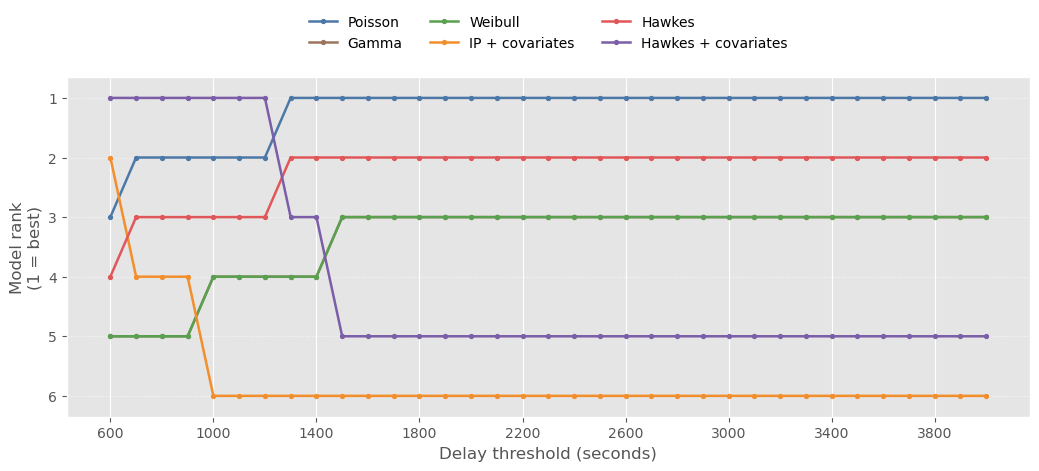

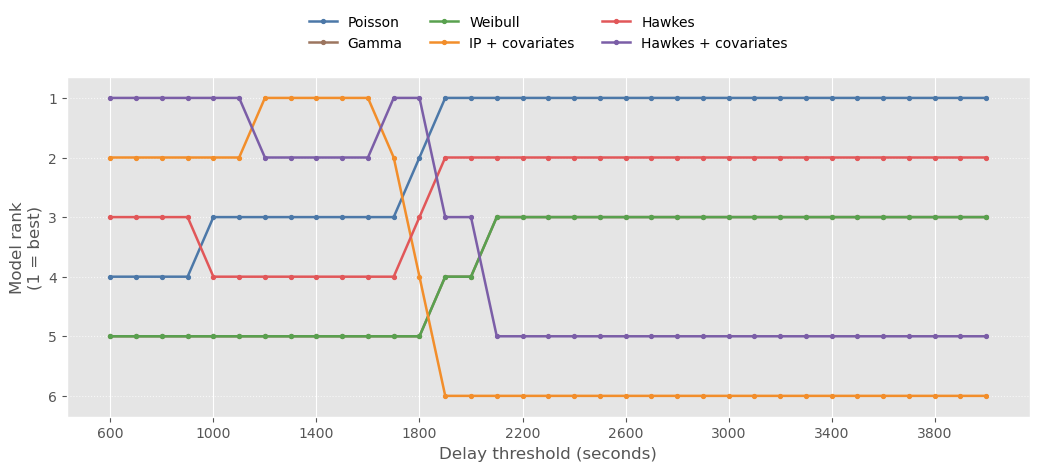

In [117]:
model_order = [
    "Poisson",
    "Gamma",
    "Weibull",
    "IP + covariates",
    "Hawkes",
    "Hawkes + covariates",
]

colours = {
    "Poisson": "#4C78A8",
    "Gamma": "#9C755F",
    "Weibull": "#59A14F",
    "IP + covariates": "#F28E2B",
    "Hawkes": "#E15759",
    "Hawkes + covariates": "#7B5EA7",
}

def plot_sensitivity_ranks(rank_column, save_stem):
    fig, ax = plt.subplots(figsize=(10.5, 4.9))

    for model in model_order:
        plot_data = threshold_grid_df[
            threshold_grid_df["Model"] == model
        ].sort_values("Threshold")

        ax.plot(
            plot_data["Threshold"],
            plot_data[rank_column],
            label=model,
            color=colours[model],
            linewidth=1.8,
            marker="o",
            markersize=2.8,
        )

    ax.set_xlabel("Delay threshold (seconds)")
    ax.set_ylabel("Model rank\n(1 = best)")
    ax.set_xticks(np.arange(600, 4001, 400))
    ax.set_yticks(range(1, 7))
    ax.set_ylim(6.35, 0.65)  # Rank 1 at the top
    ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.7)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.22),
        ncol=3,
        frameon=False,
    )

    plt.tight_layout()

    figs_dir = Path("figs")
    figs_dir.mkdir(exist_ok=True)

    fig.savefig(
    figs_dir / f"{save_stem}.svg",
    format="svg",
    bbox_inches="tight",
    )

    fig.savefig(
    figs_dir / f"{save_stem}.png",
    dpi=400,
    bbox_inches="tight",
    )

    plt.show()


# Figure for the tail-distribution evaluation section
plot_sensitivity_ranks(
    rank_column="twCRPS rank",
    save_stem="twcrps_threshold_sensitivity",
)

# Figure for the extreme-event warning evaluation section
plot_sensitivity_ranks(
    rank_column="Brier rank",
    save_stem="brier_threshold_sensitivity",
)